In [ ]:
# ================================================================
# CELL 0 — SETUP, PATHS, GPU, AND MINIMAL DRIVE STORAGE
# ================================================================
# No automatic cleanup is performed in this cell.
# The one-time cleanup is intentionally kept in a separate cell.
# ================================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import gc
import time
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
import matplotlib.colors as mcolors

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from tensorflow.keras import mixed_precision

matplotlib.rcParams["font.size"] = 12
matplotlib.rcParams["font.family"] = "serif"

RANDOM_SEED = 42
tf.keras.utils.set_random_seed(RANDOM_SEED)

# ---------------------------------------------------------------
# GPU configuration
# ---------------------------------------------------------------

GPU_DEVICES = tf.config.list_physical_devices("GPU")

for gpu_device in GPU_DEVICES:
    try:
        tf.config.experimental.set_memory_growth(gpu_device, True)
    except RuntimeError:
        pass

if GPU_DEVICES:
    mixed_precision.set_global_policy("mixed_float16")
else:
    mixed_precision.set_global_policy("float32")

print("TensorFlow version:", tf.__version__)
print("GPU devices:", GPU_DEVICES)
print("Precision policy:", mixed_precision.global_policy())

# ---------------------------------------------------------------
# Main project paths
# ---------------------------------------------------------------

OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"

MERGED_FILE = f"{OUT_PATH}/merged_iomt_dataset.csv"
MULTI_TRAIN_FILE = f"{OUT_PATH}/dl_multiclass_train_full.csv"
MULTI_TEST_FILE = f"{OUT_PATH}/dl_multiclass_test_full.csv"
MULTI_CLASSES_FILE = f"{OUT_PATH}/multiclass_classes.npy"

MULTI_RESULT_FILE = f"{OUT_PATH}/multiclass_dl_results.csv"
MULTI_MODEL_DIR = f"{OUT_PATH}/multiclass_dl_models"
MULTI_PLOT_DIR = f"{OUT_PATH}/multiclass_dl_plots"
MULTI_HISTORY_DIR = f"{OUT_PATH}/multiclass_dl_history"
MULTI_PRED_DIR = f"{OUT_PATH}/multiclass_dl_predictions"

# Temporary fault-tolerance checkpoint. Only the ACTIVE model uses it.
# BackupAndRestore overwrites the same checkpoint each epoch and it is
# removed automatically after a successful model.fit().
MULTI_RESUME_DIR = f"{OUT_PATH}/multiclass_dl_resume"

# Only ONE model's weights are kept: the current best model.
BEST_WEIGHTS_FILE = f"{MULTI_MODEL_DIR}/best_multiclass_model.weights.h5"

# Only small / essential output folders are created.
for folder in [
    MULTI_MODEL_DIR,
    MULTI_PLOT_DIR,
    MULTI_HISTORY_DIR,
    MULTI_PRED_DIR,
    MULTI_RESUME_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("\nSource / split availability")
print("Merged file              :", os.path.exists(MERGED_FILE))
print("Saved multiclass train   :", os.path.exists(MULTI_TRAIN_FILE))
print("Saved multiclass test    :", os.path.exists(MULTI_TEST_FILE))
print("Saved multiclass classes :", os.path.exists(MULTI_CLASSES_FILE))
print("\nSpace-saver mode: preprocessing arrays and probability matrices are RAM-only.")
print("Fault-tolerant resume: ENABLED for every DL model (one rolling checkpoint per active model).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Precision policy: <DTypePolicy "mixed_float16">

Source / split availability
Merged file              : True
Saved multiclass train   : True
Saved multiclass test    : True
Saved multiclass classes : True

Space-saver mode: preprocessing arrays and probability matrices are RAM-only.
Fault-tolerant resume: ENABLED for every DL model (one rolling checkpoint per active model).


In [ ]:
# ================================================================
# CELL 1 — CREATE ORIGINAL 80/20 STRATIFIED SPLIT ONLY IF MISSING
# ================================================================
# Existing saved train/test split is preserved.
# No new split is created if these files already exist.
# ================================================================

split_files_exist = all(
    os.path.exists(path)
    for path in [
        MULTI_TRAIN_FILE,
        MULTI_TEST_FILE,
        MULTI_CLASSES_FILE
    ]
)

if split_files_exist:

    print(
        "Existing multiclass train/test split found. "
        "Split creation skipped."
    )

else:

    if not os.path.exists(MERGED_FILE):
        raise FileNotFoundError(
            f"Merged dataset was not found: {MERGED_FILE}"
        )

    DROP_COLS = [
        "Flow ID",
        "Src IP",
        "Dst IP",
        "Timestamp",
        "Label"
    ]

    all_columns = pd.read_csv(
        MERGED_FILE,
        nrows=1
    ).columns.tolist()

    use_columns = [
        column
        for column in all_columns
        if column not in DROP_COLS
    ]

    df = pd.read_csv(
        MERGED_FILE,
        usecols=use_columns
    )

    df.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

    df.dropna(
        inplace=True
    )

    df.drop_duplicates(
        inplace=True
    )

    print("Cleaned merged data:", df.shape)
    print(df["Attack Name"].value_counts())

    X = df.drop(
        columns=["Attack Name"]
    ).astype(
        "float32"
    )

    y_text = df["Attack Name"]

    label_encoder = LabelEncoder()

    y = label_encoder.fit_transform(
        y_text
    )

    (
        X_train_raw,
        X_test_raw,
        y_train_raw,
        y_test_raw
    ) = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=y
    )

    train_output = X_train_raw.copy()
    train_output["Target"] = y_train_raw

    test_output = X_test_raw.copy()
    test_output["Target"] = y_test_raw

    train_output.to_csv(
        MULTI_TRAIN_FILE,
        index=False
    )

    test_output.to_csv(
        MULTI_TEST_FILE,
        index=False
    )

    np.save(
        MULTI_CLASSES_FILE,
        label_encoder.classes_
    )

    print("Saved multiclass train/test split.")
    print("Train shape:", train_output.shape)
    print("Test shape :", test_output.shape)
    print("Classes    :", label_encoder.classes_)

    del (
        df,
        X,
        y_text,
        y,
        X_train_raw,
        X_test_raw,
        y_train_raw,
        y_test_raw,
        train_output,
        test_output
    )

    gc.collect()


Existing multiclass train/test split found. Split creation skipped.


In [ ]:
# ================================================================
# CELL 2 — PROPER TRAIN / VALIDATION / TEST PREPROCESSING IN RAM
# ================================================================
# Overall split:
#   72% actual training
#    8% validation
#   20% untouched final test
#
# IMPORTANT FOR DRIVE SPACE:
#   - NO scaled .npy files are saved.
#   - NO scaler file is saved.
#   - This preprocessing is recreated each runtime from the saved
#     original 80/20 CSV split.
# ================================================================

if not all(
    os.path.exists(path)
    for path in [MULTI_TRAIN_FILE, MULTI_TEST_FILE, MULTI_CLASSES_FILE]
):
    raise FileNotFoundError(
        "Run CELL 1 first so the original train/test split exists."
    )

# ------------------------------------------------------------
# Load original 80% training portion
# ------------------------------------------------------------

train_df = pd.read_csv(MULTI_TRAIN_FILE)
y_train_full = train_df.pop("Target").to_numpy(dtype=np.int32, copy=True)

# Reduce RAM while keeping the same numeric information needed here.
train_df = train_df.astype(np.float32, copy=False)

# ------------------------------------------------------------
# Load untouched 20% final test set
# ------------------------------------------------------------

test_df = pd.read_csv(MULTI_TEST_FILE)
y_test = test_df.pop("Target").to_numpy(dtype=np.int32, copy=True)
test_df = test_df.astype(np.float32, copy=False)

feature_names = train_df.columns.astype(str).tolist()

# ------------------------------------------------------------
# Split ONLY original training portion into train + validation
# ------------------------------------------------------------

(
    X_train_df,
    X_val_df,
    y_train,
    y_val
) = train_test_split(
    train_df,
    y_train_full,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=y_train_full
)

# ------------------------------------------------------------
# Fit scaler ONLY on actual training data
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_df).astype(np.float32, copy=False)
X_val_scaled = scaler.transform(X_val_df).astype(np.float32, copy=False)
X_test_scaled = scaler.transform(test_df).astype(np.float32, copy=False)

classes = np.load(MULTI_CLASSES_FILE, allow_pickle=True)
num_classes = len(classes)

# Enforce compact label dtypes.
y_train = np.asarray(y_train, dtype=np.int32).reshape(-1)
y_val = np.asarray(y_val, dtype=np.int32).reshape(-1)
y_test = np.asarray(y_test, dtype=np.int32).reshape(-1)

print("Training features  :", X_train_scaled.shape)
print("Validation features:", X_val_scaled.shape)
print("Test features      :", X_test_scaled.shape)
print("Training labels    :", y_train.shape)
print("Validation labels  :", y_val.shape)
print("Test labels        :", y_test.shape)
print("Number of classes  :", num_classes)
print("Classes            :", classes)
print("\nNothing from preprocessing was saved to Drive.")

# Release raw DataFrames immediately.
del train_df, test_df, X_train_df, X_val_df, y_train_full
gc.collect()


Training features  : (2338102, 79)
Validation features: (259790, 79)
Test features      : (649474, 79)
Training labels    : (2338102,)
Validation labels  : (259790,)
Test labels        : (649474,)
Number of classes  : 15
Classes            : ['Benign Traffic' 'DDoS ICMP Flood' 'DDoS UDP Flood' 'DoS ICMP Flood'
 'DoS TCP Flood' 'DoS UDP Flood' 'MITM ARP Spoofing'
 'MQTT DDoS Publish Flood' 'MQTT DoS Connect Flood'
 'MQTT DoS Publish Flood' 'MQTT Malformed' 'Recon OS Scan'
 'Recon Ping Sweep' 'Recon Port Scan' 'Recon Vulnerability Scan']

Nothing from preprocessing was saved to Drive.


11

In [ ]:
# ================================================================
# CELL 3 — SELECT ONE MODEL PER RUNTIME + BUILD DATASETS
# ================================================================

SELECTED_MODEL = "AUTO"
EPOCHS = 100
SHOW_PLOTS = True

MODEL_ORDER = [
    "FNN Multiclass Full",
    "CNN Multiclass Full",
    "Simple RNN Multiclass Full",
    "GRU Multiclass Full",
    "LSTM Multiclass Full",
    "CNN-LSTM Multiclass Full",
    "CNN-LSTM-ResNet Multiclass Full"
]

MODEL_BATCH_SIZES = {
    "FNN Multiclass Full": 8192,
    "CNN Multiclass Full": 4096,
    "Simple RNN Multiclass Full": 4096,
    "GRU Multiclass Full": 1024,
    "LSTM Multiclass Full": 1024,
    "CNN-LSTM Multiclass Full": 1024,
    "CNN-LSTM-ResNet Multiclass Full": 1024
}

SEQUENCE_MODELS = {
    "CNN Multiclass Full",
    "Simple RNN Multiclass Full",
    "GRU Multiclass Full",
    "LSTM Multiclass Full",
    "CNN-LSTM Multiclass Full",
    "CNN-LSTM-ResNet Multiclass Full"
}


def safe_file_name(name):
    return (
        str(name)
        .replace(" ", "_")
        .replace("/", "-")
        .replace("\\", "-")
    )


def model_artifact_paths(name):
    safe_name = safe_file_name(name)
    return {
        "prediction": os.path.join(
            MULTI_PRED_DIR,
            f"{safe_name}_y_pred.npz"
        ),
        "history": os.path.join(
            MULTI_HISTORY_DIR,
            f"{safe_name}_history.csv"
        ),
        "resume": os.path.join(
            MULTI_RESUME_DIR,
            f"{safe_name}_resume"
        ),
        "time_state": os.path.join(
            MULTI_HISTORY_DIR,
            f"{safe_name}_resume_time.txt"
        )
    }


def result_row_exists(name):
    if not os.path.exists(MULTI_RESULT_FILE):
        return False

    result_table = pd.read_csv(MULTI_RESULT_FILE)
    return (
        "Model" in result_table.columns
        and name in result_table["Model"].astype(str).values
    )


def model_is_complete(name):
    paths = model_artifact_paths(name)
    return (
        result_row_exists(name)
        and os.path.exists(paths["prediction"])
        and os.path.exists(paths["history"])
    )


if SELECTED_MODEL == "AUTO":
    ACTIVE_MODEL = next(
        (
            model_name
            for model_name in MODEL_ORDER
            if not model_is_complete(model_name)
        ),
        None
    )
else:
    if SELECTED_MODEL not in MODEL_ORDER:
        raise ValueError(
            "SELECTED_MODEL must be 'AUTO' or one exact model name:\n"
            + "\n".join(MODEL_ORDER)
        )
    ACTIVE_MODEL = SELECTED_MODEL

if ACTIVE_MODEL is None:
    print("All seven models are already complete.")
else:
    print("Model selected for this runtime:", ACTIVE_MODEL)
    print("Batch size:", MODEL_BATCH_SIZES[ACTIVE_MODEL])
    print("Epoch ceiling:", EPOCHS)
    print("Sequence input:", ACTIVE_MODEL in SEQUENCE_MODELS)


def add_channel(features, labels):
    return tf.expand_dims(features, axis=-1), labels


def create_datasets_for_model(model_name):
    batch_size = MODEL_BATCH_SIZES[model_name]

    train_dataset = tf.data.Dataset.from_tensor_slices(
        (X_train_scaled, y_train)
    )
    train_dataset = train_dataset.shuffle(
        buffer_size=min(50000, len(y_train)),
        seed=RANDOM_SEED,
        reshuffle_each_iteration=True
    )

    validation_dataset = tf.data.Dataset.from_tensor_slices(
        (X_val_scaled, y_val)
    )
    test_dataset = tf.data.Dataset.from_tensor_slices(
        (X_test_scaled, y_test)
    )

    if model_name in SEQUENCE_MODELS:
        train_dataset = train_dataset.map(
            add_channel,
            num_parallel_calls=tf.data.AUTOTUNE
        )
        validation_dataset = validation_dataset.map(
            add_channel,
            num_parallel_calls=tf.data.AUTOTUNE
        )
        test_dataset = test_dataset.map(
            add_channel,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    train_dataset = train_dataset.batch(
        batch_size,
        drop_remainder=False
    ).prefetch(tf.data.AUTOTUNE)

    validation_dataset = validation_dataset.batch(
        batch_size,
        drop_remainder=False
    ).prefetch(tf.data.AUTOTUNE)

    test_dataset = test_dataset.batch(
        batch_size,
        drop_remainder=False
    ).prefetch(tf.data.AUTOTUNE)

    return train_dataset, validation_dataset, test_dataset


All seven models are already complete.


In [ ]:
# ================================================================
# CELL 4 — TRAINING, METRICS, AND SPACE-SAVER SAVING
# ================================================================

MULTI_RESULT_COLUMNS = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC AUC",
    "PR AUC",
    "Train Time"
]

if os.path.exists(MULTI_RESULT_FILE):
    multi_dl_results_df = pd.read_csv(
        MULTI_RESULT_FILE
    )
    print("Previous multiclass DL results loaded.")
    display(multi_dl_results_df)
else:
    multi_dl_results_df = pd.DataFrame(
        columns=MULTI_RESULT_COLUMNS
    )
    print("New multiclass DL result table created.")


def show_or_close(fig):
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


def save_history_csv(history, name):
    safe_name = safe_file_name(name)
    history_file = os.path.join(
        MULTI_HISTORY_DIR,
        f"{safe_name}_history.csv"
    )

    history_df = pd.DataFrame(
        history.history
    )

    history_df.to_csv(
        history_file,
        index=False,
        float_format="%.7g"
    )

    return history_df, history_file


def plot_loss_curve(history_df, name, train_time=None):
    if history_df is None or history_df.empty:
        print("Loss plot skipped because no history was available.")
        return

    required_columns = {"loss", "val_loss"}
    if not required_columns.issubset(history_df.columns):
        print("Loss plot skipped because loss columns were unavailable.")
        return

    fig, ax = plt.subplots(
        figsize=(7.6, 4.2),
        dpi=160
    )

    epochs_axis = np.arange(
        1,
        len(history_df) + 1
    )

    ax.plot(
        epochs_axis,
        history_df["loss"],
        linewidth=2.3,
        label="Training Loss"
    )
    ax.plot(
        epochs_axis,
        history_df["val_loss"],
        linewidth=2.3,
        label="Validation Loss"
    )

    title = f"Training and Validation Loss - {name}"
    if train_time is not None and np.isfinite(train_time):
        title += f"\nTraining time: {train_time / 60:.1f} min"

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=10
    )
    ax.set_xlabel("Epoch", fontsize=14)
    ax.set_ylabel("Loss", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.30)
    ax.legend(fontsize=12, frameon=True)
    fig.tight_layout()

    png_file = os.path.join(
        MULTI_PLOT_DIR,
        f"{safe_file_name(name)}_loss_curve.png"
    )

    fig.savefig(
        png_file,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    show_or_close(fig)

    print("Loss curve saved:", png_file)


def plot_confusion_matrix_readable(cm, class_names, name):
    class_names = [
        str(class_name)
        for class_name in class_names
    ]

    norm = mcolors.PowerNorm(
        gamma=0.35,
        vmin=0,
        vmax=max(float(cm.max()), 1.0)
    )

    fig, ax = plt.subplots(
        figsize=(24, 20),
        dpi=160
    )

    image = ax.imshow(
        cm,
        cmap="Blues",
        norm=norm,
        aspect="auto"
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )
    colorbar.set_label(
        "Number of Samples",
        rotation=270,
        labelpad=24,
        fontsize=14
    )
    colorbar.ax.tick_params(labelsize=11)

    ax.set_title(
        f"Confusion Matrix - {name}",
        fontsize=19,
        fontweight="bold",
        pad=16
    )
    ax.set_xlabel(
        "Predicted Class",
        fontsize=16,
        labelpad=10
    )
    ax.set_ylabel(
        "Actual Class",
        fontsize=16,
        labelpad=10
    )

    positions = np.arange(
        len(class_names)
    )
    ax.set_xticks(positions)
    ax.set_yticks(positions)
    ax.set_xticklabels(
        class_names,
        rotation=60,
        ha="right",
        fontsize=11
    )
    ax.set_yticklabels(
        class_names,
        fontsize=11
    )
    ax.tick_params(length=0)

    for row_index in range(cm.shape[0]):
        for column_index in range(cm.shape[1]):
            value = int(
                cm[row_index, column_index]
            )
            text_color = (
                "white"
                if norm(value) > 0.55
                else "black"
            )
            ax.text(
                column_index,
                row_index,
                f"{value:,}",
                ha="center",
                va="center",
                fontsize=17,
                fontweight="semibold",
                color=text_color
            )

    ax.set_xticks(
        np.arange(
            -0.5,
            len(class_names),
            1
        ),
        minor=True
    )
    ax.set_yticks(
        np.arange(
            -0.5,
            len(class_names),
            1
        ),
        minor=True
    )
    ax.grid(
        which="minor",
        linewidth=0.45,
        alpha=0.35
    )
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    fig.tight_layout()

    png_file = os.path.join(
        MULTI_PLOT_DIR,
        f"{safe_file_name(name)}_confusion_matrix.png"
    )

    fig.savefig(
        png_file,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    show_or_close(fig)

    print("Confusion matrix saved:", png_file)


def compute_curve_metrics(y_true, probability):
    y_true_binary = label_binarize(
        y_true,
        classes=np.arange(len(classes))
    )

    fpr, tpr, _ = roc_curve(
        y_true_binary.ravel(),
        probability.ravel()
    )
    roc_auc_value = auc(
        fpr,
        tpr
    )

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true_binary.ravel(),
        probability.ravel()
    )
    pr_auc_value = average_precision_score(
        y_true_binary,
        probability,
        average="micro"
    )

    return (
        y_true_binary,
        fpr,
        tpr,
        roc_auc_value,
        precision_curve,
        recall_curve,
        pr_auc_value
    )


def plot_roc_curve_compact(
    fpr,
    tpr,
    roc_auc_value,
    name
):
    fig, ax = plt.subplots(
        figsize=(7.6, 4.2),
        dpi=160
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"Micro-average AUC = {roc_auc_value:.4f}"
    )
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.5
    )

    ax.set_title(
        f"Multiclass ROC Curve - {name}",
        fontsize=16,
        fontweight="bold",
        pad=10
    )
    ax.set_xlabel(
        "False Positive Rate",
        fontsize=14
    )
    ax.set_ylabel(
        "True Positive Rate",
        fontsize=14
    )
    ax.tick_params(
        axis="both",
        labelsize=12
    )
    ax.legend(
        fontsize=12,
        loc="lower right"
    )
    ax.grid(True, alpha=0.30)
    fig.tight_layout()

    png_file = os.path.join(
        MULTI_PLOT_DIR,
        f"{safe_file_name(name)}_roc_curve.png"
    )

    fig.savefig(
        png_file,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    show_or_close(fig)

    print("ROC curve saved:", png_file)


def plot_pr_curve_compact(
    precision_curve,
    recall_curve,
    pr_auc_value,
    name
):
    fig, ax = plt.subplots(
        figsize=(7.6, 4.2),
        dpi=160
    )

    ax.plot(
        recall_curve,
        precision_curve,
        linewidth=2.5,
        label=f"Micro-average AP = {pr_auc_value:.4f}"
    )

    ax.set_title(
        f"Multiclass Precision-Recall Curve - {name}",
        fontsize=16,
        fontweight="bold",
        pad=10
    )
    ax.set_xlabel("Recall", fontsize=14)
    ax.set_ylabel("Precision", fontsize=14)
    ax.tick_params(
        axis="both",
        labelsize=12
    )
    ax.legend(
        fontsize=12,
        loc="lower left"
    )
    ax.grid(True, alpha=0.30)
    fig.tight_layout()

    png_file = os.path.join(
        MULTI_PLOT_DIR,
        f"{safe_file_name(name)}_precision_recall_curve.png"
    )

    fig.savefig(
        png_file,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    show_or_close(fig)

    print("Precision-recall curve saved:", png_file)


def calculate_multiclass_metrics(name, y_true, probability):
    y_true = np.asarray(
        y_true,
        dtype=np.int32
    ).reshape(-1)

    probability = np.asarray(
        probability,
        dtype=np.float32
    )

    prediction = np.argmax(
        probability,
        axis=1
    ).astype(
        np.int32
    )

    if len(y_true) != len(prediction):
        raise ValueError(
            f"y_true has {len(y_true):,} rows but predictions have "
            f"{len(prediction):,} rows."
        )

    accuracy = accuracy_score(
        y_true,
        prediction
    )
    precision = precision_score(
        y_true,
        prediction,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_true,
        prediction,
        average="weighted",
        zero_division=0
    )
    f1_value = f1_score(
        y_true,
        prediction,
        average="weighted",
        zero_division=0
    )

    (
        y_true_binary,
        fpr,
        tpr,
        roc_auc_value,
        precision_curve,
        recall_curve,
        pr_auc_value
    ) = compute_curve_metrics(
        y_true,
        probability
    )

    confusion = confusion_matrix(
        y_true,
        prediction,
        labels=np.arange(len(classes))
    )

    print("\n" + "=" * 72)
    print("Model:", name)
    print("=" * 72)
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1_value:.4f}")
    print("\nClassification Report:\n")
    print(
        classification_report(
            y_true,
            prediction,
            labels=np.arange(len(classes)),
            target_names=[str(value) for value in classes],
            zero_division=0,
            digits=4
        )
    )

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1_value,
        "ROC AUC": roc_auc_value,
        "PR AUC": pr_auc_value
    }

    plot_payload = {
        "prediction": prediction,
        "confusion": confusion,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc_value,
        "precision_curve": precision_curve,
        "recall_curve": recall_curve,
        "pr_auc": pr_auc_value
    }

    print("Classification report was displayed only; it was NOT saved to Drive.")

    return metrics, plot_payload


def generate_all_png_plots(
    name,
    history_df,
    train_time,
    plot_payload
):
    plot_loss_curve(
        history_df=history_df,
        name=name,
        train_time=train_time
    )
    plot_confusion_matrix_readable(
        cm=plot_payload["confusion"],
        class_names=classes,
        name=name
    )
    plot_roc_curve_compact(
        fpr=plot_payload["fpr"],
        tpr=plot_payload["tpr"],
        roc_auc_value=plot_payload["roc_auc"],
        name=name
    )
    plot_pr_curve_compact(
        precision_curve=plot_payload["precision_curve"],
        recall_curve=plot_payload["recall_curve"],
        pr_auc_value=plot_payload["pr_auc"],
        name=name
    )


def update_result_table(
    name,
    metrics,
    train_time
):
    global multi_dl_results_df

    result_row = pd.DataFrame(
        [{
            "Model": name,
            **metrics,
            "Train Time": train_time
        }]
    )

    if "Model" in multi_dl_results_df.columns:
        multi_dl_results_df = multi_dl_results_df[
            multi_dl_results_df["Model"].astype(str) != name
        ]

    multi_dl_results_df = pd.concat(
        [
            multi_dl_results_df,
            result_row
        ],
        ignore_index=True
    )

    multi_dl_results_df = multi_dl_results_df[
        MULTI_RESULT_COLUMNS
    ]

    multi_dl_results_df.to_csv(
        MULTI_RESULT_FILE,
        index=False
    )

    print("Result saved:", MULTI_RESULT_FILE)


def calculate_and_plot_multiclass_metrics(
    name,
    y_true,
    prob
):
    metrics, plot_payload = calculate_multiclass_metrics(
        name=name,
        y_true=y_true,
        probability=prob
    )

    generate_all_png_plots(
        name=name,
        history_df=None,
        train_time=np.nan,
        plot_payload=plot_payload
    )

    return metrics




def previous_best_f1_excluding(name):
    if multi_dl_results_df.empty or "Model" not in multi_dl_results_df.columns:
        return -np.inf

    other_rows = multi_dl_results_df[
        multi_dl_results_df["Model"].astype(str) != name
    ].copy()

    if other_rows.empty:
        return -np.inf

    values = pd.to_numeric(other_rows["F1"], errors="coerce").dropna()
    return float(values.max()) if not values.empty else -np.inf


def save_compact_predictions(name, prediction):
    paths = model_artifact_paths(name)

    if num_classes <= 256:
        pred_dtype = np.uint8
    elif num_classes <= 65536:
        pred_dtype = np.uint16
    else:
        pred_dtype = np.uint32

    np.savez_compressed(
        paths["prediction"],
        y_pred=np.asarray(prediction, dtype=pred_dtype)
    )
    print("Compact y_pred saved:", paths["prediction"])


def save_current_best_weights(model, name, f1_value):
    # Keep only ONE weight file in Drive.
    if os.path.exists(BEST_WEIGHTS_FILE):
        os.remove(BEST_WEIGHTS_FILE)

    model.save_weights(BEST_WEIGHTS_FILE)

    print("Current best model:", name)
    print("Current best weighted F1:", f"{f1_value:.6f}")
    print("Only best-model weights saved:", BEST_WEIGHTS_FILE)


def run_multi_dl_ds(
    name,
    model_builder,
    train_dataset,
    validation_dataset,
    test_dataset,
    y_true,
    epochs=100
):
    """
    Space-saver + fault-tolerant execution for EVERY model:
      - resumes automatically from the last COMPLETED epoch after disconnect
      - keeps only ONE rolling BackupAndRestore checkpoint for the active model
      - checkpoint is removed after model.fit() finishes successfully
      - epoch history is appended across resumed runtimes
      - no full probability cache
      - no per-model full .keras files
      - only tiny y_pred/history/results are kept permanently
      - only the current best model keeps permanent weights
    """
    global multi_dl_results_df

    if model_is_complete(name):
        print(f"{name} is already complete. Training was skipped.")
        return None

    tf.keras.backend.clear_session()
    gc.collect()

    paths = model_artifact_paths(name)
    backup_directory = paths["resume"]
    history_file = paths["history"]
    time_state_file = paths["time_state"]

    # A non-empty backup directory means a previous model.fit() was
    # interrupted before it completed. BackupAndRestore will recover the
    # model weights, optimizer state, and epoch number automatically.
    resume_checkpoint_exists = (
        os.path.isdir(backup_directory)
        and any(os.scandir(backup_directory))
    )

    # If there is no valid resume checkpoint, any history belonging to an
    # old/incomplete pre-resume attempt must not be appended to a fresh run.
    if not resume_checkpoint_exists:
        if os.path.exists(history_file):
            os.remove(history_file)
        if os.path.exists(time_state_file):
            os.remove(time_state_file)

    class CumulativeEpochTime(tf.keras.callbacks.Callback):
        """Keep total completed-epoch training time across runtime restarts."""

        def __init__(self, state_file):
            super().__init__()
            self.state_file = state_file
            self.previous_seconds = 0.0
            self.session_start = None

            if os.path.exists(self.state_file):
                try:
                    with open(self.state_file, "r", encoding="utf-8") as handle:
                        self.previous_seconds = float(handle.read().strip() or 0.0)
                except Exception:
                    self.previous_seconds = 0.0

        def on_train_begin(self, logs=None):
            self.session_start = time.time()

        def on_epoch_end(self, epoch, logs=None):
            current_total = (
                self.previous_seconds
                + (time.time() - self.session_start)
            )
            with open(self.state_file, "w", encoding="utf-8") as handle:
                handle.write(f"{current_total:.6f}")

    cumulative_time_callback = CumulativeEpochTime(time_state_file)

    model = model_builder()

    callbacks = [
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=backup_directory,
            save_freq="epoch",
            delete_checkpoint=True
        ),
        tf.keras.callbacks.CSVLogger(
            history_file,
            append=resume_checkpoint_exists
        ),
        cumulative_time_callback,
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.TerminateOnNaN()
    ]

    print("\n" + "=" * 72)
    print("Training:", name)
    print("Batch size:", MODEL_BATCH_SIZES[name])
    print("Epoch ceiling:", epochs)
    print("EarlyStopping patience:", 15)
    print("Validation source: separate validation set")
    print("Final test set is NOT used during model.fit()")
    print("Fault-tolerant epoch resume: ENABLED")
    print("Resume checkpoint:", backup_directory)

    if resume_checkpoint_exists:
        print("Resume status: previous interrupted training FOUND.")
        print("Training will continue from the last completed epoch automatically.")
    else:
        print("Resume status: no previous checkpoint; starting this model fresh.")

    print("Checkpoint storage: ONE rolling checkpoint only; old epoch is overwritten.")
    print("=" * 72)

    start_time = time.time()

    # IMPORTANT:
    # No manual initial_epoch is needed. BackupAndRestore restores the
    # saved epoch number at the beginning of model.fit().
    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=2
    )

    session_train_time = time.time() - start_time

    # Prefer cumulative completed-epoch time across all resumed sessions.
    # If the tiny state file is unavailable, fall back to this session time.
    train_time = session_train_time
    if os.path.exists(time_state_file):
        try:
            with open(time_state_file, "r", encoding="utf-8") as handle:
                train_time = float(handle.read().strip())
        except Exception:
            train_time = session_train_time

    # CSVLogger writes one small row after each completed epoch. Because it
    # uses append=True on a resumed run, this file contains the full history
    # across all runtime sessions instead of only the final session.
    if not os.path.exists(history_file):
        raise FileNotFoundError(
            f"Training history file was not created: {history_file}"
        )

    history_df = pd.read_csv(history_file)

    # Protect against an extremely rare duplicate epoch row if an interruption
    # happens exactly while end-of-epoch callbacks are being written.
    if "epoch" in history_df.columns:
        history_df = (
            history_df
            .drop_duplicates(subset="epoch", keep="last")
            .sort_values("epoch")
            .reset_index(drop=True)
        )
        history_df.to_csv(
            history_file,
            index=False,
            float_format="%.7g"
        )

    print("Complete small history CSV saved:", history_file)

    # Probability is RAM-only and is deleted after metrics.
    probability = model.predict(
        test_dataset,
        verbose=0
    ).astype(np.float32, copy=False)

    y_true_np = np.asarray(y_true, dtype=np.int32).reshape(-1)
    prediction = np.argmax(probability, axis=1).astype(np.int32)

    metrics, plot_payload = calculate_multiclass_metrics(
        name=name,
        y_true=y_true_np,
        probability=probability
    )

    # Save only compact class predictions for later McNemar testing.
    save_compact_predictions(
        name=name,
        prediction=prediction
    )

    previous_best = previous_best_f1_excluding(name)
    is_current_best = metrics["F1"] > previous_best

    if is_current_best:
        save_current_best_weights(
            model=model,
            name=name,
            f1_value=metrics["F1"]
        )
    else:
        print("This model is not the current best; no permanent model weights were saved.")

    print("No full probability matrix was saved to Drive.")

    # Result row is written LAST and serves as the completion marker.
    update_result_table(
        name=name,
        metrics=metrics,
        train_time=train_time
    )

    # BackupAndRestore normally deletes its temporary checkpoint after a
    # successful fit. Remove an empty leftover directory too, if one remains.
    if os.path.isdir(backup_directory):
        shutil.rmtree(
            backup_directory,
            ignore_errors=True
        )

    if os.path.exists(time_state_file):
        os.remove(time_state_file)

    print(f"Training time this runtime: {session_train_time / 60:.2f} minutes")
    print(f"Cumulative completed-epoch training time: {train_time / 60:.2f} minutes")
    print("Resume checkpoint removed because this model completed successfully.")

    del model, probability, prediction, history, plot_payload
    gc.collect()
    tf.keras.backend.clear_session()

    print("\nCompleted:", name)
    print("Restart the runtime before training the next model.")

    return None



Previous multiclass DL results loaded.


,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Train Time
0,FNN Multiclass Full,0.971649,0.967797,0.971649,0.964392,0.999795,0.997359,1330.350986
1,CNN Multiclass Full,0.965874,0.954917,0.965874,0.952710,0.999628,0.995317,16052.728197
2,Simple RNN Multiclass Full,0.964571,0.944529,0.964571,0.949554,0.999487,0.993929,1334.590405
3,GRU Multiclass Full,0.981039,0.980074,0.981039,0.980079,0.999908,0.998801,10119.793570
4,LSTM Multiclass Full,0.971603,0.969196,0.971603,0.964978,0.999785,0.997232,45247.738215
5,CNN-LSTM Multiclass Full,0.971883,0.968652,0.971883,0.965426,0.999780,0.997172,13870.023465
6,CNN-LSTM-ResNet Multiclass Full,0.980427,0.979008,0.980427,0.978981,0.999905,0.998735,24469.539914


In [ ]:
# ================================================================
# CELL 5 — ORIGINAL MODEL ARCHITECTURES + GRU LR TUNING
# ================================================================
# All architectures are preserved. Only GRU learning rate is tuned
# from 0.001 to 0.0005. Output heads remain float32.

INPUT_FEATURES = X_train_scaled.shape[1]


def compile_multiclass_model(
    model,
    optimizer
):
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
        steps_per_execution=32
    )
    return model


def build_fnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(INPUT_FEATURES,)
        ),
        tf.keras.layers.Dense(
            128,
            activation="relu"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            dtype="float32"
        )
    ])

    return compile_multiclass_model(
        model,
        tf.keras.optimizers.Adam()
    )


def build_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(INPUT_FEATURES, 1)
        ),
        tf.keras.layers.Conv1D(
            64,
            3,
            activation="relu"
        ),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Conv1D(
            32,
            3,
            activation="relu"
        ),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            dtype="float32"
        )
    ])

    return compile_multiclass_model(
        model,
        tf.keras.optimizers.Adam()
    )


def build_simple_rnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(INPUT_FEATURES, 1)
        ),
        tf.keras.layers.SimpleRNN(
            128,
            activation="tanh",
            return_sequences=False
        ),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            dtype="float32"
        )
    ])

    return compile_multiclass_model(
        model,
        tf.keras.optimizers.Adam(
            learning_rate=0.001
        )
    )


def build_gru():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(INPUT_FEATURES, 1)
        ),
        tf.keras.layers.GRU(
            128,
            activation="tanh",
            return_sequences=False
        ),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(
            64,
            activation="relu"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            dtype="float32"
        )
    ])

    return compile_multiclass_model(
        model,
        tf.keras.optimizers.Adam(
            learning_rate=0.0005
        )
    )


def build_lstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(INPUT_FEATURES, 1)
        ),
        tf.keras.layers.LSTM(
            32,
            activation="tanh"
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(
            32,
            activation="relu"
        ),
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            dtype="float32"
        )
    ])

    return compile_multiclass_model(
        model,
        tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0
        )
    )


def build_cnn_lstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(INPUT_FEATURES, 1)
        ),
        tf.keras.layers.Conv1D(
            filters=16,
            kernel_size=5,
            strides=2,
            padding="same",
            activation="relu"
        ),
        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),
        tf.keras.layers.LSTM(
            16,
            return_sequences=False
        ),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(
            16,
            activation="relu"
        ),
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            dtype="float32"
        )
    ])

    return compile_multiclass_model(
        model,
        tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0
        )
    )


def build_cnn_lstm_resnet():
    inputs = tf.keras.layers.Input(
        shape=(INPUT_FEATURES, 1)
    )

    x = tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(inputs)

    shortcut = x

    x = tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same"
    )(x)

    x = tf.keras.layers.Add()([
        x,
        shortcut
    ])

    x = tf.keras.layers.Activation(
        "relu"
    )(x)

    x = tf.keras.layers.MaxPooling1D(
        pool_size=2
    )(x)

    x = tf.keras.layers.LSTM(
        128,
        activation="tanh",
        return_sequences=False
    )(x)

    x = tf.keras.layers.Dropout(
        0.3
    )(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(
        0.2
    )(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    return compile_multiclass_model(
        model,
        tf.keras.optimizers.Adam(
            learning_rate=0.001
        )
    )


MODEL_BUILDERS = {
    "FNN Multiclass Full": build_fnn,
    "CNN Multiclass Full": build_cnn,
    "Simple RNN Multiclass Full": build_simple_rnn,
    "GRU Multiclass Full": build_gru,
    "LSTM Multiclass Full": build_lstm,
    "CNN-LSTM Multiclass Full": build_cnn_lstm,
    "CNN-LSTM-ResNet Multiclass Full": build_cnn_lstm_resnet
}

print("Model builders ready.")

Model builders ready.


In [ ]:
# ================================================================
# CELL 6 — RUN THE ONE SELECTED MODEL
# ================================================================
# With SELECTED_MODEL = "AUTO":
#   - first runtime -> first incomplete model
#   - restart runtime and run CELL 0 through CELL 6 again
#   - next incomplete model will be selected automatically
# ================================================================

if ACTIVE_MODEL is None:
    print("Nothing to train. All seven models are complete.")
else:
    (
        selected_train_ds,
        selected_val_ds,
        selected_test_ds
    ) = create_datasets_for_model(ACTIVE_MODEL)

    run_multi_dl_ds(
        name=ACTIVE_MODEL,
        model_builder=MODEL_BUILDERS[ACTIVE_MODEL],
        train_dataset=selected_train_ds,
        validation_dataset=selected_val_ds,
        test_dataset=selected_test_ds,
        y_true=y_test,
        epochs=EPOCHS
    )

    del selected_train_ds, selected_val_ds, selected_test_ds
    gc.collect()


Nothing to train. All seven models are complete.


In [ ]:
# ================================================================
# CURRENT SAVED RESULT TABLE
# ================================================================

if os.path.exists(MULTI_RESULT_FILE):
    results = (
        pd.read_csv(MULTI_RESULT_FILE)
        .sort_values(
            "F1",
            ascending=False
        )
        .reset_index(drop=True)
    )
    display(results.round(4))
else:
    print("No multiclass DL result file was found.")

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Train Time
0,GRU Multiclass Full,0.9810,0.9801,0.9810,0.9801,0.9999,0.9988,10119.7936
1,CNN-LSTM-ResNet Multiclass Full,0.9804,0.9790,0.9804,0.9790,0.9999,0.9987,24469.5399
2,CNN-LSTM Multiclass Full,0.9719,0.9687,0.9719,0.9654,0.9998,0.9972,13870.0235
3,LSTM Multiclass Full,0.9716,0.9692,0.9716,0.9650,0.9998,0.9972,45247.7382
4,FNN Multiclass Full,0.9716,0.9678,0.9716,0.9644,0.9998,0.9974,1330.3510
5,CNN Multiclass Full,0.9659,0.9549,0.9659,0.9527,0.9996,0.9953,16052.7282
6,Simple RNN Multiclass Full,0.9646,0.9445,0.9646,0.9496,0.9995,0.9939,1334.5904


In [ ]:
# ================================================================
# LOAD THE CURRENT BEST MODEL FROM THE SINGLE SAVED WEIGHT FILE
# ================================================================

if not os.path.exists(MULTI_RESULT_FILE):
    raise FileNotFoundError(
        "Run at least one multiclass model first; result CSV was not found."
    )

best_row = (
    pd.read_csv(MULTI_RESULT_FILE)
    .sort_values("F1", ascending=False)
    .iloc[0]
)

best_model_name = str(best_row["Model"])

if not os.path.exists(BEST_WEIGHTS_FILE):
    raise FileNotFoundError(
        f"Best-model weight file was not found: {BEST_WEIGHTS_FILE}"
    )

if best_model_name not in MODEL_BUILDERS:
    raise KeyError(f"No model builder was found for: {best_model_name}")

tf.keras.backend.clear_session()
gc.collect()

best_multiclass_model = MODEL_BUILDERS[best_model_name]()
best_multiclass_model.load_weights(BEST_WEIGHTS_FILE)

print("Best model:", best_model_name)
print("Loaded weights from:", BEST_WEIGHTS_FILE)
print("Input shape:", best_multiclass_model.input_shape)
print("Output shape:", best_multiclass_model.output_shape)


Best model: GRU Multiclass Full
Loaded weights from: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_models/best_multiclass_model.weights.h5
Input shape: (None, 79, 1)
Output shape: (None, 15)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


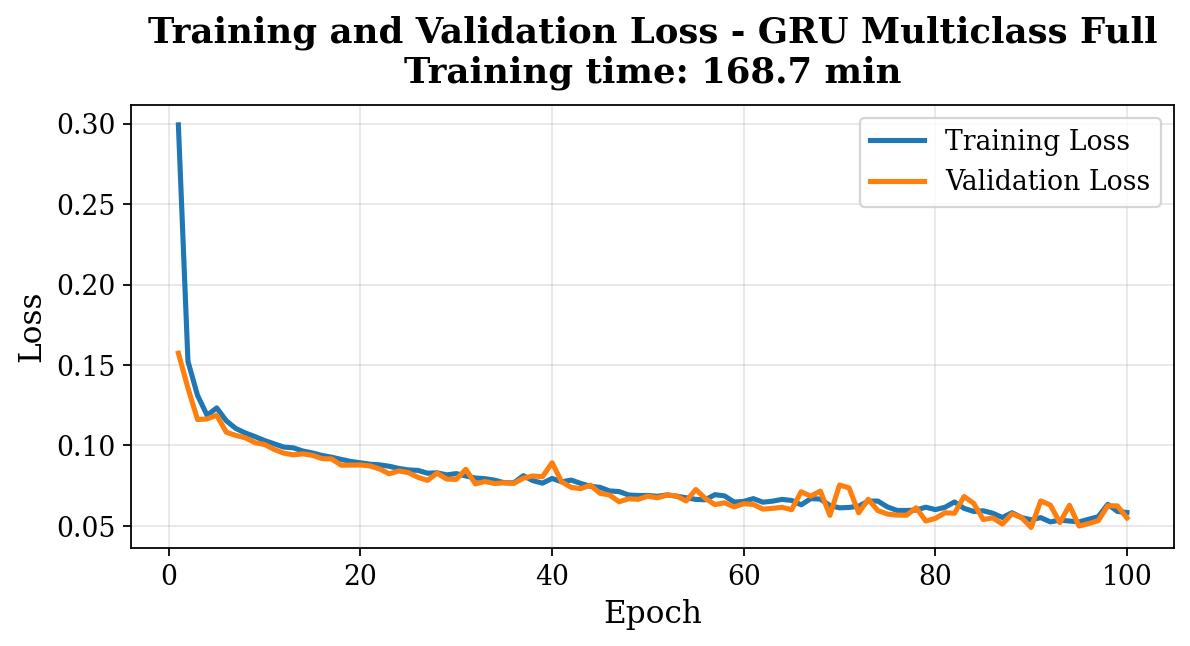

Loss curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_plots/GRU_Multiclass_Full_loss_curve.png


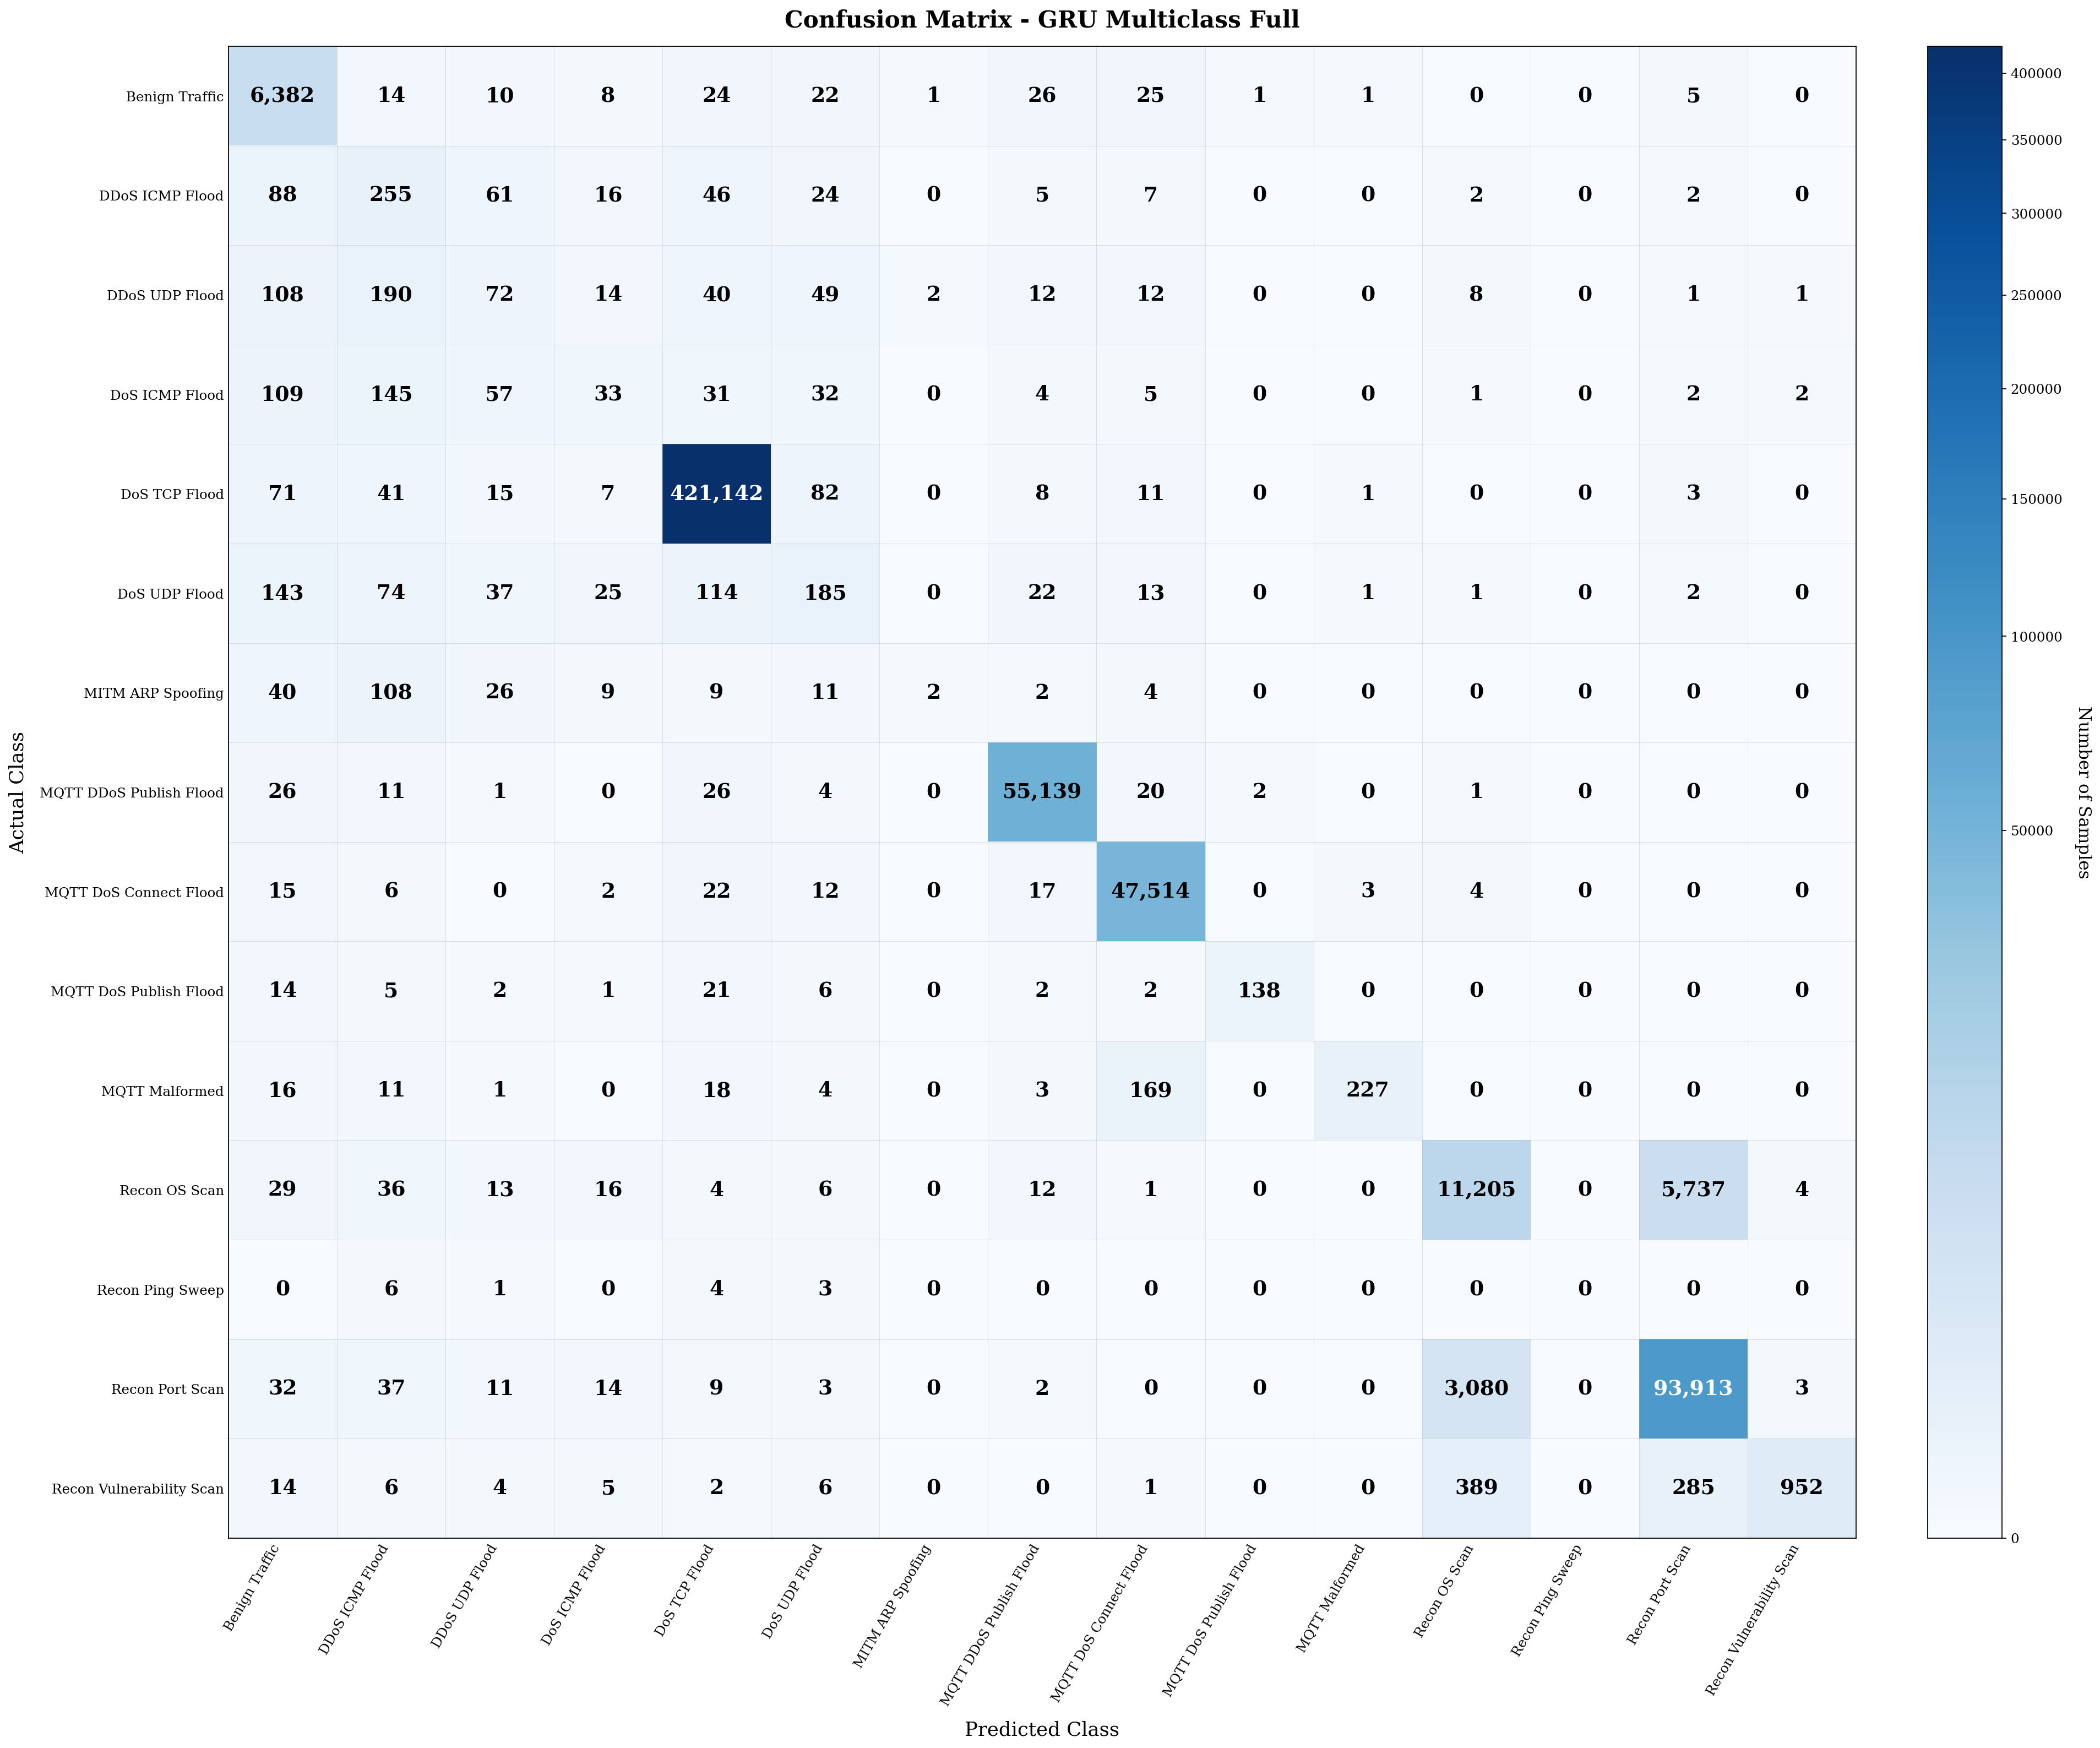

Confusion matrix saved: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_plots/GRU_Multiclass_Full_confusion_matrix.png


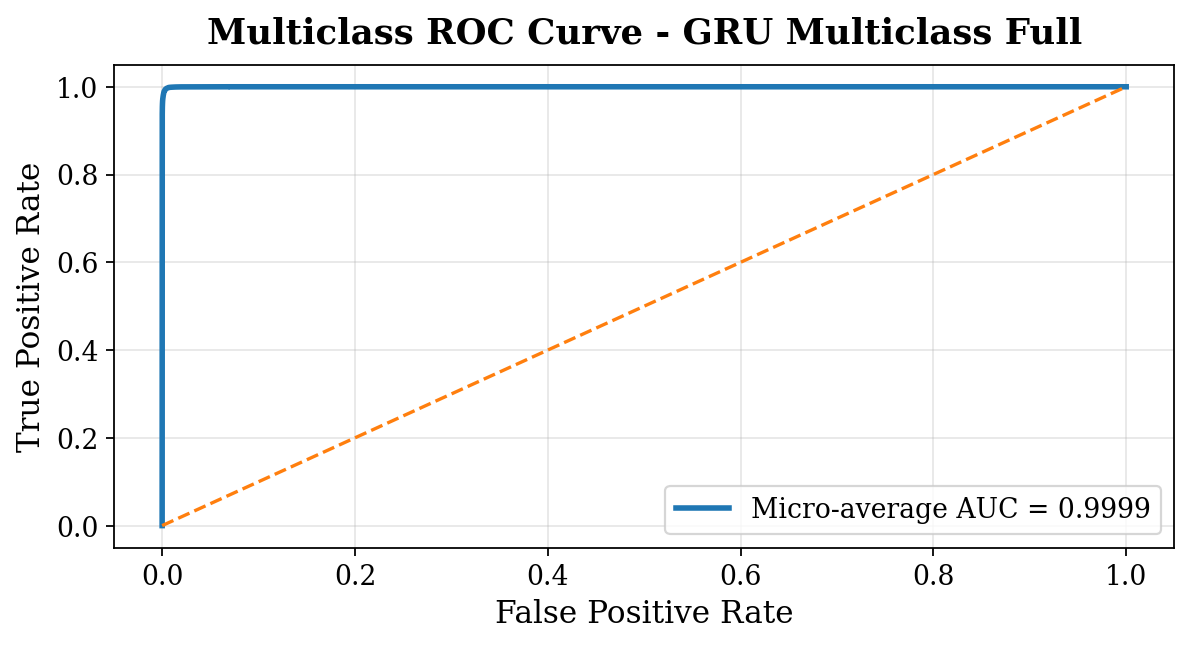

ROC curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_plots/GRU_Multiclass_Full_roc_curve.png


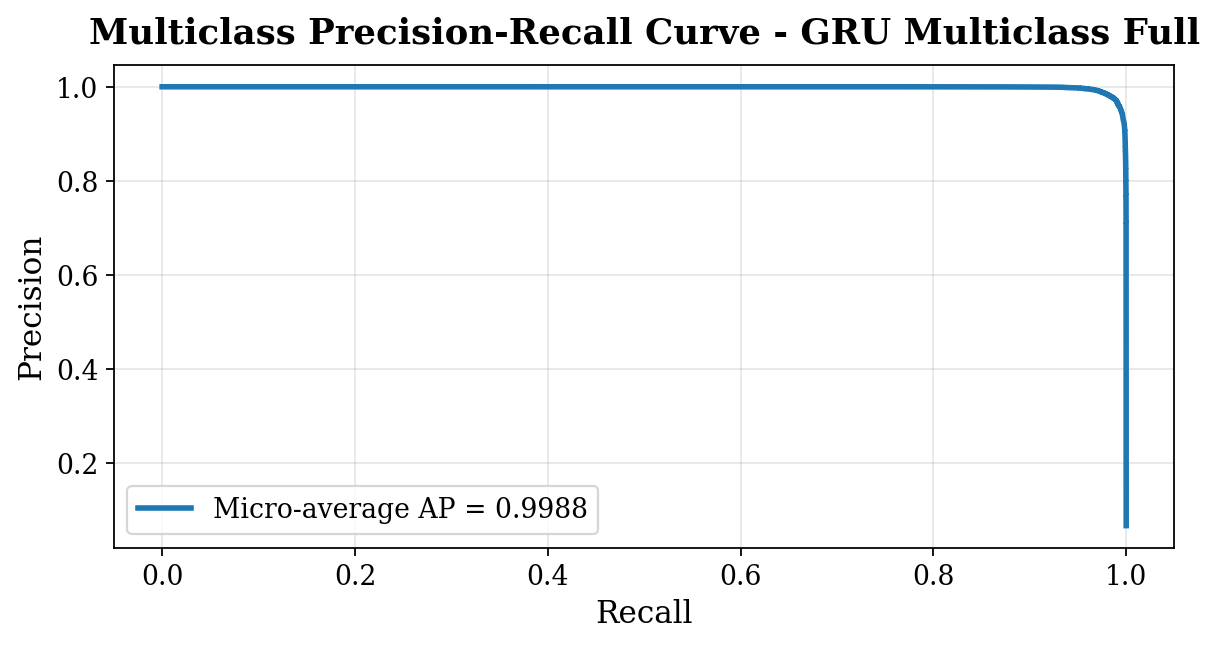

Precision-recall curve saved: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_plots/GRU_Multiclass_Full_precision_recall_curve.png
Final best-model report saved: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_final_best_report/GRU_Multiclass_Full_classification_report.csv
Final best-model plots saved in: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_plots
Full probability matrix was kept in RAM only and was NOT saved.


33284

In [ ]:
# ================================================================
# OPTIONAL — SAVE FINAL BEST-MODEL REPORT + 4 PAPER FIGURES
# ================================================================
# Run this ONLY after all models are finished and only when you
# actually need the final paper artifacts. Until then, skip it.
# This predicts in RAM and saves only the FINAL BEST model outputs.
# ================================================================

FINAL_BEST_REPORT_DIR = f"{OUT_PATH}/multiclass_dl_final_best_report"
os.makedirs(FINAL_BEST_REPORT_DIR, exist_ok=True)

# Build the correct test dataset for the best model.
_, _, best_test_ds = create_datasets_for_model(best_model_name)

best_probability = best_multiclass_model.predict(
    best_test_ds,
    verbose=0
).astype(np.float32, copy=False)

best_prediction = np.argmax(best_probability, axis=1).astype(np.int32)

# Save ONE classification report for the final best model.
best_report = classification_report(
    y_test,
    best_prediction,
    labels=np.arange(len(classes)),
    target_names=[str(v) for v in classes],
    zero_division=0,
    digits=4,
    output_dict=True
)

best_report_file = os.path.join(
    FINAL_BEST_REPORT_DIR,
    f"{safe_file_name(best_model_name)}_classification_report.csv"
)

pd.DataFrame(best_report).transpose().to_csv(
    best_report_file,
    float_format="%.7g"
)

# Recompute plot payload in RAM. This function also prints the report,
# but its old per-model report-save path is not used in space-saver mode.
# We therefore compute the required curves directly here.

(
    _,
    best_fpr,
    best_tpr,
    best_roc_auc,
    best_precision_curve,
    best_recall_curve,
    best_pr_auc
) = compute_curve_metrics(y_test, best_probability)

best_confusion = confusion_matrix(
    y_test,
    best_prediction,
    labels=np.arange(len(classes))
)

best_history_file = model_artifact_paths(best_model_name)["history"]
best_history_df = pd.read_csv(best_history_file)

best_result_row = pd.read_csv(MULTI_RESULT_FILE)
best_result_row = best_result_row[
    best_result_row["Model"].astype(str) == best_model_name
].iloc[-1]
best_train_time = float(best_result_row["Train Time"])

# Save only four final best-model PNGs.
plot_loss_curve(best_history_df, best_model_name, best_train_time)
plot_confusion_matrix_readable(best_confusion, classes, best_model_name)
plot_roc_curve_compact(best_fpr, best_tpr, best_roc_auc, best_model_name)
plot_pr_curve_compact(
    best_precision_curve,
    best_recall_curve,
    best_pr_auc,
    best_model_name
)

print("Final best-model report saved:", best_report_file)
print("Final best-model plots saved in:", MULTI_PLOT_DIR)
print("Full probability matrix was kept in RAM only and was NOT saved.")

del best_probability, best_prediction, best_test_ds
gc.collect()


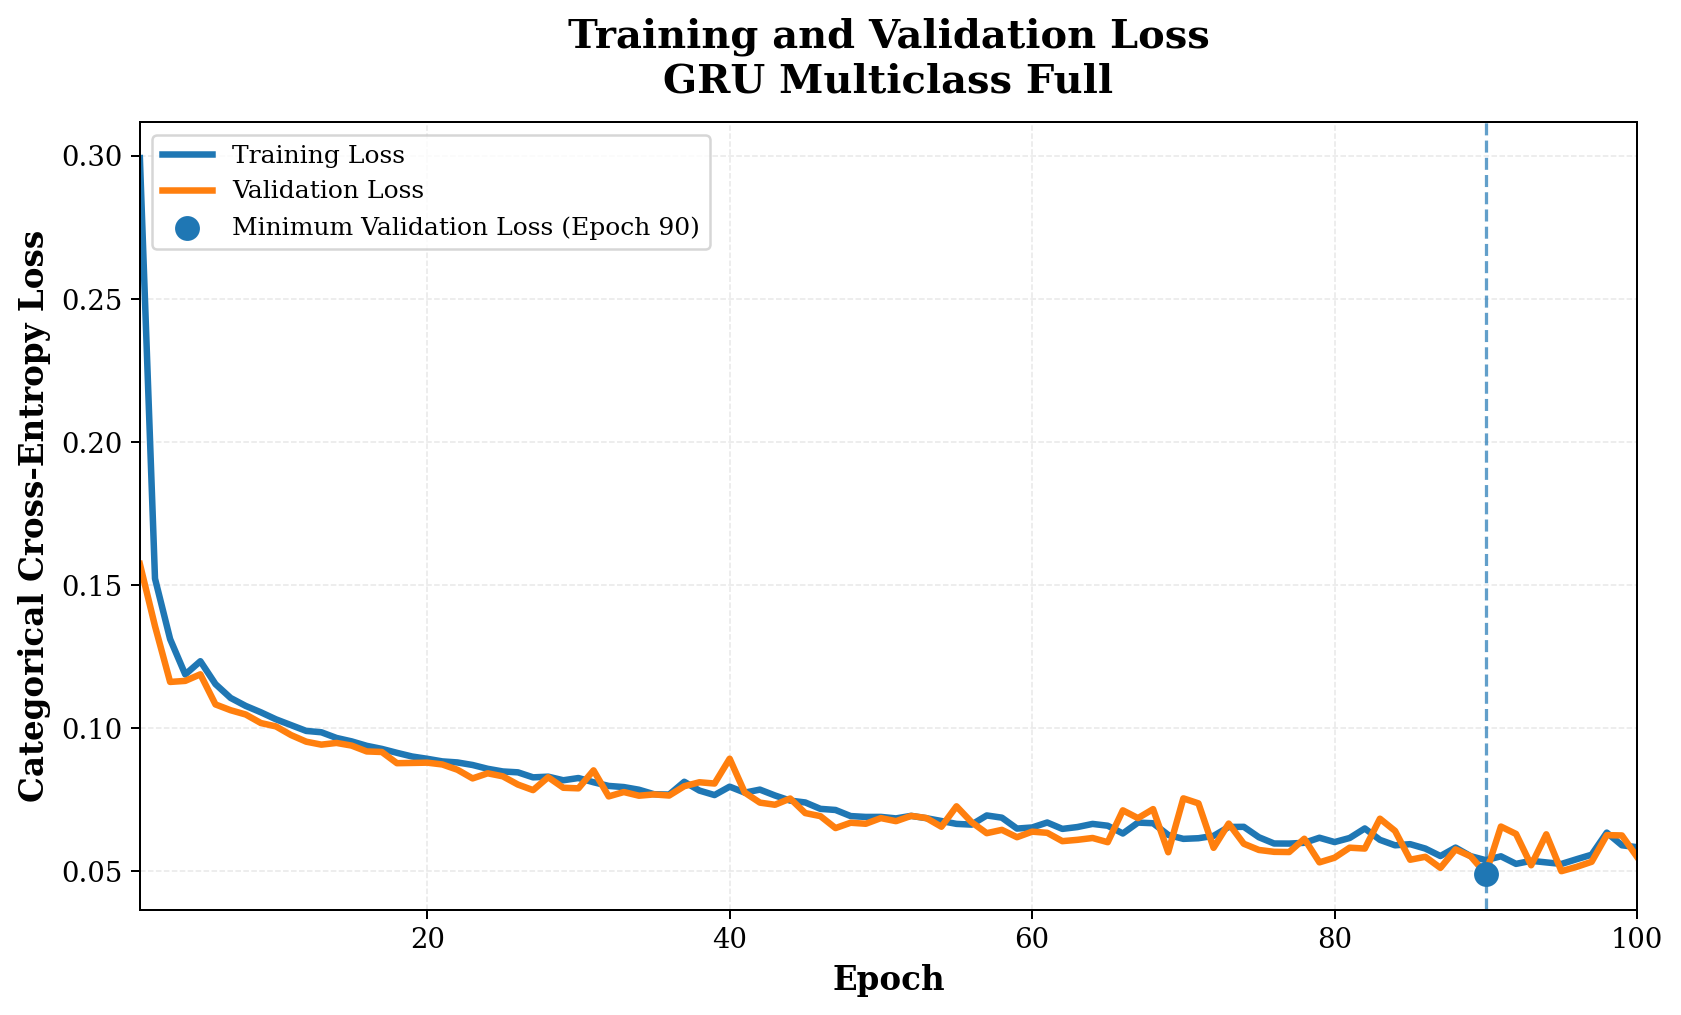

,Model,Completed Epochs,Minimum Validation-Loss Epoch,Training Loss at Best Epoch,Minimum Validation Loss
0,GRU Multiclass Full,100,90,0.05381581,0.04908896



History source:
/content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_history/GRU_Multiclass_Full_history.csv

Training-validation loss figure saved:
/content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_plots/GRU_Multiclass_Full_training_validation_loss.png


In [ ]:
# ================================================================
# DL MULTICLASS TRAINING AND VALIDATION LOSS FIGURE
# BEST COMPLETED MODEL OR SELECTED MODEL — NO RETRAINING
# PNG ONLY
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ----------------------------------------------------------------
# 1. Configuration
# ----------------------------------------------------------------

# "AUTO" = select the highest-F1 completed model.
# Or provide an exact model name, for example:
# "CNN-LSTM-ResNet Multiclass Full"
LOSS_MODEL_NAME = "AUTO"

OUT_PATH = "/content/drive/MyDrive/IoMT_Thesis_2024"

MULTI_RESULT_FILE = os.path.join(
    OUT_PATH,
    "multiclass_dl_results.csv"
)

MULTI_HISTORY_DIR = os.path.join(
    OUT_PATH,
    "multiclass_dl_history"
)

MULTI_PLOT_DIR = os.path.join(
    OUT_PATH,
    "multiclass_dl_plots"
)

os.makedirs(
    MULTI_PLOT_DIR,
    exist_ok=True
)


# ----------------------------------------------------------------
# 2. File-name helper
# ----------------------------------------------------------------

def safe_file_name(name):

    return (
        str(name)
        .replace(" ", "_")
        .replace("/", "-")
        .replace("\\", "-")
    )


# ----------------------------------------------------------------
# 3. Locate a saved history file
# ----------------------------------------------------------------

def find_history_file(model_name):

    safe_name = safe_file_name(
        model_name
    )

    possible_files = [
        os.path.join(
            MULTI_HISTORY_DIR,
            f"{safe_name}_history.csv"
        ),
        os.path.join(
            MULTI_HISTORY_DIR,
            f"{safe_name}_epoch_log.csv"
        )
    ]

    for file_path in possible_files:

        if os.path.exists(file_path):

            history_preview = pd.read_csv(
                file_path,
                nrows=5
            )

            lower_columns = {
                str(column).strip().lower()
                for column in history_preview.columns
            }

            if {
                "loss",
                "val_loss"
            }.issubset(lower_columns):

                return file_path

    return None


# ----------------------------------------------------------------
# 4. Select the model
# ----------------------------------------------------------------

if LOSS_MODEL_NAME == "AUTO":

    if not os.path.exists(
        MULTI_RESULT_FILE
    ):

        raise FileNotFoundError(
            "Multiclass result CSV was not found:\n"
            + MULTI_RESULT_FILE
        )

    result_table = pd.read_csv(
        MULTI_RESULT_FILE
    )

    required_columns = {
        "Model",
        "F1"
    }

    missing_columns = required_columns.difference(
        result_table.columns
    )

    if missing_columns:

        raise ValueError(
            "The result table is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    result_table["F1"] = pd.to_numeric(
        result_table["F1"],
        errors="coerce"
    )

    result_table = (
        result_table
        .dropna(
            subset=[
                "Model",
                "F1"
            ]
        )
        .drop_duplicates(
            subset="Model",
            keep="last"
        )
        .sort_values(
            "F1",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    selected_model_name = None
    selected_history_file = None

    for candidate_model in result_table[
        "Model"
    ].astype(str):

        candidate_history_file = find_history_file(
            candidate_model
        )

        if candidate_history_file is not None:

            selected_model_name = candidate_model
            selected_history_file = candidate_history_file
            break

    if selected_model_name is None:

        raise FileNotFoundError(
            "No completed model with a valid saved history "
            "file containing loss and val_loss was found."
        )

else:

    selected_model_name = str(
        LOSS_MODEL_NAME
    )

    selected_history_file = find_history_file(
        selected_model_name
    )

    if selected_history_file is None:

        raise FileNotFoundError(
            "No valid history file was found for:\n"
            f"{selected_model_name}\n\n"
            "Expected folder:\n"
            f"{MULTI_HISTORY_DIR}"
        )


# ----------------------------------------------------------------
# 5. Load the history
# ----------------------------------------------------------------

history_df = pd.read_csv(
    selected_history_file
)

column_lookup = {
    str(column).strip().lower(): column
    for column in history_df.columns
}

loss_column = column_lookup.get(
    "loss"
)

validation_loss_column = column_lookup.get(
    "val_loss"
)

if loss_column is None or validation_loss_column is None:

    raise ValueError(
        "The history file must contain both 'loss' "
        "and 'val_loss' columns."
    )


history_df["Training Loss"] = pd.to_numeric(
    history_df[loss_column],
    errors="coerce"
)

history_df["Validation Loss"] = pd.to_numeric(
    history_df[validation_loss_column],
    errors="coerce"
)


# ----------------------------------------------------------------
# 6. Create a correct epoch column
# ----------------------------------------------------------------

if "epoch" in column_lookup:

    epoch_column = column_lookup[
        "epoch"
    ]

    history_df["Epoch"] = pd.to_numeric(
        history_df[epoch_column],
        errors="coerce"
    )

    valid_epoch_values = history_df[
        "Epoch"
    ].dropna()

    # CSVLogger normally starts epochs from zero.
    if (
        not valid_epoch_values.empty
        and valid_epoch_values.min() == 0
    ):

        history_df["Epoch"] = (
            history_df["Epoch"] + 1
        )

else:

    history_df["Epoch"] = np.arange(
        1,
        len(history_df) + 1
    )


history_df = (
    history_df[
        [
            "Epoch",
            "Training Loss",
            "Validation Loss"
        ]
    ]
    .dropna()
    .drop_duplicates(
        subset="Epoch",
        keep="last"
    )
    .sort_values(
        "Epoch"
    )
    .reset_index(
        drop=True
    )
)


if history_df.empty:

    raise RuntimeError(
        "No valid training and validation loss values "
        "were found in the history file."
    )


# ----------------------------------------------------------------
# 7. Find the minimum validation-loss epoch
# ----------------------------------------------------------------

best_row_index = int(
    history_df[
        "Validation Loss"
    ].idxmin()
)

best_epoch = int(
    history_df.loc[
        best_row_index,
        "Epoch"
    ]
)

minimum_validation_loss = float(
    history_df.loc[
        best_row_index,
        "Validation Loss"
    ]
)

training_loss_at_best_epoch = float(
    history_df.loc[
        best_row_index,
        "Training Loss"
    ]
)


# ----------------------------------------------------------------
# 8. Create the conference-ready figure
# ----------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9.5, 5.8),
    dpi=180,
    facecolor="white"
)

ax.plot(
    history_df["Epoch"],
    history_df["Training Loss"],
    linewidth=2.6,
    label="Training Loss"
)

ax.plot(
    history_df["Epoch"],
    history_df["Validation Loss"],
    linewidth=2.6,
    label="Validation Loss"
)

ax.scatter(
    best_epoch,
    minimum_validation_loss,
    s=80,
    zorder=5,
    label=(
        f"Minimum Validation Loss "
        f"(Epoch {best_epoch})"
    )
)

ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.3,
    alpha=0.70
)

ax.set_title(
    (
        "Training and Validation Loss\n"
        f"{selected_model_name}"
    ),
    fontsize=16,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Epoch",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Categorical Cross-Entropy Loss",
    fontsize=13,
    fontweight="bold"
)

ax.tick_params(
    axis="both",
    labelsize=11
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.30
)

ax.legend(
    fontsize=10,
    frameon=True
)

ax.set_xlim(
    max(
        1,
        int(
            history_df["Epoch"].min()
        )
    ),
    int(
        history_df["Epoch"].max()
    )
)

fig.tight_layout()


# ----------------------------------------------------------------
# 9. Save only PNG and display
# ----------------------------------------------------------------

loss_figure_path = os.path.join(
    MULTI_PLOT_DIR,
    (
        f"{safe_file_name(selected_model_name)}_"
        "training_validation_loss.png"
    )
)

fig.savefig(
    loss_figure_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


# ----------------------------------------------------------------
# 10. Display numerical information
# ----------------------------------------------------------------

loss_summary = pd.DataFrame(
    [
        {
            "Model": selected_model_name,
            "Completed Epochs": len(
                history_df
            ),
            "Minimum Validation-Loss Epoch":
                best_epoch,
            "Training Loss at Best Epoch":
                training_loss_at_best_epoch,
            "Minimum Validation Loss":
                minimum_validation_loss
        }
    ]
)

display(
    loss_summary.style.format(
        {
            "Training Loss at Best Epoch":
                "{:.8f}",
            "Minimum Validation Loss":
                "{:.8f}"
        }
    )
)

print("\nHistory source:")
print(selected_history_file)

print("\nTraining-validation loss figure saved:")
print(loss_figure_path)

In [ ]:
!pip install -q shap lime

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from lime.lime_tabular import LimeTabularExplainer

XAI_PATH = f"{OUT_PATH}/multiclass_xai"
os.makedirs(XAI_PATH, exist_ok=True)

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [ ]:
# ================================================================
# SPACE-SAVER MODEL STORAGE STATUS
# ================================================================

print("Permanent training storage is intentionally minimal: one best weight file + tiny result/history/y_pred files.")
print("Weights file exists:", os.path.exists(BEST_WEIGHTS_FILE))
print("Weights path:", BEST_WEIGHTS_FILE)

if os.path.exists(MULTI_RESULT_FILE):
    ranking = pd.read_csv(MULTI_RESULT_FILE).sort_values("F1", ascending=False)
    display(ranking)


Permanent training storage is intentionally minimal: one best weight file + tiny result/history/y_pred files.
Weights file exists: True
Weights path: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_models/best_multiclass_model.weights.h5


,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Train Time
3,GRU Multiclass Full,0.981039,0.980074,0.981039,0.980079,0.999908,0.998801,10119.793570
6,CNN-LSTM-ResNet Multiclass Full,0.980427,0.979008,0.980427,0.978981,0.999905,0.998735,24469.539914
5,CNN-LSTM Multiclass Full,0.971883,0.968652,0.971883,0.965426,0.999780,0.997172,13870.023465
4,LSTM Multiclass Full,0.971603,0.969196,0.971603,0.964978,0.999785,0.997232,45247.738215
0,FNN Multiclass Full,0.971649,0.967797,0.971649,0.964392,0.999795,0.997359,1330.350986
1,CNN Multiclass Full,0.965874,0.954917,0.965874,0.952710,0.999628,0.995317,16052.728197
2,Simple RNN Multiclass Full,0.964571,0.944529,0.964571,0.949554,0.999487,0.993929,1334.590405


In [ ]:
def model_uses_sequence_input(model):
    input_shape = model.input_shape
    if isinstance(input_shape, list):
        input_shape = input_shape[0]
    return len(input_shape) == 3


def to_model_input(x_2d, model):
    x_2d = np.asarray(x_2d, dtype=np.float32)
    if model_uses_sequence_input(model):
        return np.expand_dims(x_2d, axis=-1)
    return x_2d


def make_predict_function(model):
    def predict_function(x_2d):
        x_model = to_model_input(x_2d, model)
        return model.predict(
            x_model,
            batch_size=512,
            verbose=0
        )
    return predict_function


def shap_values_for_target_class(
    raw_shap,
    sample_index,
    class_index,
    n_features,
    n_classes
):
    """
    Handles old and new SHAP output formats:
    list[class] -> (samples, features[, 1])
    ndarray      -> (samples, features, classes)
    ndarray      -> (samples, features, 1, classes)
    """
    if hasattr(raw_shap, "values"):
        raw_shap = raw_shap.values

    if isinstance(raw_shap, list):
        values = np.asarray(raw_shap[class_index])
        vector = values[sample_index].reshape(-1)
        if vector.size != n_features:
            raise ValueError(
                f"Unexpected SHAP vector length: {vector.size}"
            )
        return vector

    values = np.asarray(raw_shap)

    if values.ndim == 2:
        vector = values[sample_index]

    elif values.ndim == 3:
        if values.shape[-1] == n_classes:
            vector = values[
                sample_index, :, class_index
            ]
        else:
            vector = values[sample_index].reshape(-1)

    elif values.ndim == 4:
        if values.shape[-1] == n_classes:
            vector = values[
                sample_index, :, :, class_index
            ].reshape(-1)
        else:
            vector = values[sample_index].reshape(-1)

    else:
        raise ValueError(
            f"Unsupported SHAP output shape: {values.shape}"
        )

    if vector.size != n_features:
        raise ValueError(
            f"Expected {n_features} SHAP feature values, "
            f"received {vector.size}."
        )

    return vector


In [ ]:
# ================================================================
# MULTICLASS DL McNEMAR TEST — COMPACT y_pred FILES ONLY
# BEST MODEL VS ALL OTHER COMPLETED MODELS — NO RETRAINING
# ================================================================

import os
import sys
import subprocess
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from statsmodels.stats.contingency_tables import mcnemar
    from statsmodels.stats.multitest import multipletests
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    from statsmodels.stats.contingency_tables import mcnemar
    from statsmodels.stats.multitest import multipletests

ALPHA = 0.05
NUMBER_OF_COMPARISON_MODELS = None
MCNEMAR_OUTPUT_FILE = os.path.join(
    OUT_PATH,
    "multiclass_dl_best_vs_other_models_mcnemar_holm.csv"
)


def prediction_file_path(model_name):
    return os.path.join(
        MULTI_PRED_DIR,
        f"{safe_file_name(model_name)}_y_pred.npz"
    )


def load_y_pred(model_name):
    path = prediction_file_path(model_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Prediction file not found for {model_name}: {path}")

    with np.load(path, allow_pickle=False) as saved:
        if "y_pred" not in saved.files:
            raise KeyError(f"'y_pred' not found in {path}")
        y_pred = np.asarray(saved["y_pred"], dtype=np.int32).reshape(-1)

    return y_pred, path


if not os.path.exists(MULTI_RESULT_FILE):
    raise FileNotFoundError("The multiclass DL result CSV was not found.")

ranking_table = pd.read_csv(MULTI_RESULT_FILE)
ranking_table["F1"] = pd.to_numeric(ranking_table["F1"], errors="coerce")
ranking_table = (
    ranking_table
    .dropna(subset=["Model", "F1"])
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

completed_models = [
    str(model_name)
    for model_name in ranking_table["Model"]
    if os.path.exists(prediction_file_path(str(model_name)))
]

if len(completed_models) < 2:
    raise RuntimeError(
        "At least two completed models with compact y_pred files are required."
    )

reference_model_name = completed_models[0]
comparison_model_names = completed_models[1:]

if NUMBER_OF_COMPARISON_MODELS is not None:
    comparison_model_names = comparison_model_names[:NUMBER_OF_COMPARISON_MODELS]

reference_y_true = np.asarray(y_test, dtype=np.int32).reshape(-1)
reference_y_pred, reference_path = load_y_pred(reference_model_name)

if len(reference_y_pred) != len(reference_y_true):
    raise ValueError("Reference y_pred length does not match the current untouched test set.")

reference_correct = reference_y_pred == reference_y_true

print("Reference model:", reference_model_name)
print("Reference compact prediction file:", reference_path)
print("Paired test observations:", f"{len(reference_y_true):,}")

statistical_rows = []

for comparison_model_name in comparison_model_names:
    comparison_y_pred, comparison_path = load_y_pred(comparison_model_name)

    if len(comparison_y_pred) != len(reference_y_true):
        raise ValueError(
            f"{comparison_model_name} prediction length does not match the test set."
        )

    comparison_correct = comparison_y_pred == reference_y_true

    b = int(np.sum(reference_correct & ~comparison_correct))
    c = int(np.sum(~reference_correct & comparison_correct))
    both_correct = int(np.sum(reference_correct & comparison_correct))
    both_wrong = int(np.sum(~reference_correct & ~comparison_correct))
    discordant = b + c

    table = np.asarray(
        [[both_correct, b], [c, both_wrong]],
        dtype=np.int64
    )

    if discordant == 0:
        method = "No discordant predictions"
        statistic = 0.0
        p_value = 1.0
    elif discordant < 25:
        result = mcnemar(table, exact=True, correction=False)
        method = "Exact McNemar test"
        statistic = float(result.statistic)
        p_value = float(result.pvalue)
    else:
        result = mcnemar(table, exact=False, correction=True)
        method = "McNemar chi-square with correction"
        statistic = float(result.statistic)
        p_value = float(result.pvalue)

    statistical_rows.append({
        "Reference Model": reference_model_name,
        "Comparison Model": comparison_model_name,
        "Reference Correct / Comparison Wrong": b,
        "Reference Wrong / Comparison Correct": c,
        "Discordant Predictions": discordant,
        "Test Method": method,
        "Statistic": statistic,
        "P-value": p_value
    })

mcnemar_df = pd.DataFrame(statistical_rows)

if not mcnemar_df.empty:
    reject, adjusted_p, _, _ = multipletests(
        mcnemar_df["P-value"].to_numpy(dtype=float),
        alpha=ALPHA,
        method="holm"
    )
    mcnemar_df["Holm-adjusted P-value"] = adjusted_p
    mcnemar_df["Holm Significance (α=0.05)"] = np.where(
        reject,
        "Statistically significant",
        "Not statistically significant"
    )

mcnemar_df.to_csv(
    MCNEMAR_OUTPUT_FILE,
    index=False,
    float_format="%.7g"
)

mcnemar_results = mcnemar_df.copy()

display(mcnemar_df)
print("Saved:", MCNEMAR_OUTPUT_FILE)
print("Only compact y_pred files were required; probability matrices were not stored.")


Reference model: GRU Multiclass Full
Reference compact prediction file: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_predictions/GRU_Multiclass_Full_y_pred.npz
Paired test observations: 649,474


,Reference Model,Comparison Model,Reference Correct / Comparison Wrong,Reference Wrong / Comparison Correct,Discordant Predictions,Test Method,Statistic,P-value,Holm-adjusted P-value,Holm Significance (α=0.05)
0,GRU Multiclass Full,CNN-LSTM-ResNet Multiclass Full,5573,5176,10749,McNemar chi-square with correction,14.588892,0.000134,0.000134,Statistically significant
1,GRU Multiclass Full,CNN-LSTM Multiclass Full,9671,3725,13396,McNemar chi-square with correction,2638.326739,0.000000,0.000000,Statistically significant
2,GRU Multiclass Full,LSTM Multiclass Full,9498,3370,12868,McNemar chi-square with correction,2917.324293,0.000000,0.000000,Statistically significant
3,GRU Multiclass Full,FNN Multiclass Full,10062,3964,14026,McNemar chi-square with correction,2650.321474,0.000000,0.000000,Statistically significant
4,GRU Multiclass Full,CNN Multiclass Full,13036,3187,16223,McNemar chi-square with correction,5978.123898,0.000000,0.000000,Statistically significant
5,GRU Multiclass Full,Simple RNN Multiclass Full,13887,3192,17079,McNemar chi-square with correction,6696.038176,0.000000,0.000000,Statistically significant


Saved: /content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_best_vs_other_models_mcnemar_holm.csv
Only compact y_pred files were required; probability matrices were not stored.


In [ ]:
# ================================================================
# HIGH-PRECISION McNEMAR P-VALUES
# FIXES 0.000000e+00 CAUSED BY FLOAT64 UNDERFLOW
# ================================================================

import os
import mpmath as mp
import numpy as np
import pandas as pd

from IPython.display import display


# ----------------------------------------------------------------
# 1. Check the existing McNemar result table
# ----------------------------------------------------------------

if "mcnemar_results" not in globals():
    raise RuntimeError(
        "Run the McNemar statistical-test cell before this cell."
    )

required_columns = {
    "Statistic",
    "Reference Correct / Comparison Wrong",
    "Reference Wrong / Comparison Correct"
}

missing_columns = required_columns.difference(
    mcnemar_results.columns
)

if missing_columns:
    raise ValueError(
        "The McNemar table is missing required columns: "
        f"{sorted(missing_columns)}"
    )


# ----------------------------------------------------------------
# 2. Set arbitrary numerical precision
# ----------------------------------------------------------------

mp.mp.dps = 100


# ----------------------------------------------------------------
# 3. High-precision chi-square survival function for df = 1
# ----------------------------------------------------------------

def chi_square_df1_survival_high_precision(statistic):

    statistic_mp = mp.mpf(
        str(statistic)
    )

    return (
        mp.gammainc(
            mp.mpf("0.5"),
            statistic_mp / 2,
            mp.inf
        )
        /
        mp.gamma(
            mp.mpf("0.5")
        )
    )


def format_high_precision_scientific(
    value,
    decimal_places=6
):

    value = mp.mpf(value)

    if value == 0:
        return "0"

    exponent = int(
        mp.floor(
            mp.log10(value)
        )
    )

    mantissa = (
        value
        /
        mp.power(
            10,
            exponent
        )
    )

    return (
        f"{float(mantissa):.{decimal_places}f}"
        f"e{exponent:+d}"
    )


# ----------------------------------------------------------------
# 4. Recalculate raw p-values with high precision
# ----------------------------------------------------------------

high_precision_raw_p_values = []

for statistic in mcnemar_results["Statistic"]:

    high_precision_p = (
        chi_square_df1_survival_high_precision(
            statistic
        )
    )

    high_precision_raw_p_values.append(
        high_precision_p
    )


# ----------------------------------------------------------------
# 5. Apply Holm correction with high precision
# ----------------------------------------------------------------

number_of_comparisons = len(
    high_precision_raw_p_values
)

sorted_indices = sorted(
    range(number_of_comparisons),
    key=lambda index: high_precision_raw_p_values[index]
)

high_precision_holm_values = [
    mp.mpf("0")
    for _ in range(number_of_comparisons)
]

running_adjusted_value = mp.mpf("0")


for rank, original_index in enumerate(
    sorted_indices
):

    remaining_comparisons = (
        number_of_comparisons
        - rank
    )

    candidate_adjusted_value = (
        remaining_comparisons
        *
        high_precision_raw_p_values[
            original_index
        ]
    )

    candidate_adjusted_value = min(
        candidate_adjusted_value,
        mp.mpf("1")
    )

    running_adjusted_value = max(
        running_adjusted_value,
        candidate_adjusted_value
    )

    high_precision_holm_values[
        original_index
    ] = running_adjusted_value


# ----------------------------------------------------------------
# 6. Add readable high-precision columns
# ----------------------------------------------------------------

mcnemar_results[
    "P-value (high precision)"
] = [
    format_high_precision_scientific(
        value
    )
    for value in high_precision_raw_p_values
]


mcnemar_results[
    "Holm-adjusted P-value (high precision)"
] = [
    format_high_precision_scientific(
        value
    )
    for value in high_precision_holm_values
]


mcnemar_results[
    "-log10(P-value)"
] = [
    float(
        -mp.log10(value)
    )
    for value in high_precision_raw_p_values
]


mcnemar_results[
    "-log10(Holm-adjusted P-value)"
] = [
    float(
        -mp.log10(value)
    )
    for value in high_precision_holm_values
]


# ----------------------------------------------------------------
# 7. Add paired accuracy difference
# ----------------------------------------------------------------

if "reference_y_true" in globals():

    paired_observation_count = len(
        reference_y_true
    )

else:

    paired_observation_count = 649474

    print(
        "Warning: reference_y_true was unavailable. "
        "Using the reported paired observation count:",
        paired_observation_count
    )


mcnemar_results[
    "Paired Accuracy Difference (%)"
] = (
    (
        mcnemar_results[
            "Reference Correct / Comparison Wrong"
        ]
        -
        mcnemar_results[
            "Reference Wrong / Comparison Correct"
        ]
    )
    /
    paired_observation_count
    *
    100
)


# ----------------------------------------------------------------
# 8. Add a paper-ready reporting column
# ----------------------------------------------------------------

mcnemar_results[
    "Paper-ready P-value"
] = [
    "p < 0.001"
    if value < mp.mpf("0.001")
    else f"p = {float(value):.4f}"
    for value in high_precision_holm_values
]

# ----------------------------------------------------------------
# 8b. Add significance after Holm correction
# ----------------------------------------------------------------

alpha = mp.mpf("0.05")

mcnemar_results[
    "Significance after Holm correction"
] = [
    "Statistically significant"
    if value < alpha
    else "Not statistically significant"
    for value in high_precision_holm_values
]

# ----------------------------------------------------------------
# 9. Display the corrected result
# ----------------------------------------------------------------

display_columns = [
    "Reference Model",
    "Comparison Model",
    "Reference Correct / Comparison Wrong",
    "Reference Wrong / Comparison Correct",
    "Discordant Predictions",
    "Statistic",
    "P-value (high precision)",
    "Holm-adjusted P-value (high precision)",
    "Paired Accuracy Difference (%)",
    "Paper-ready P-value",
    "Significance after Holm correction"
]


display(
    mcnemar_results[
        display_columns
    ].style.format(
        {
            "Statistic": "{:.6f}",
            "Paired Accuracy Difference (%)": "{:.4f}",
            "-log10(P-value)": "{:.4f}",
            "-log10(Holm-adjusted P-value)": "{:.4f}"
        }
    )
)


# ----------------------------------------------------------------
# 10. Save a separate high-precision CSV
# ----------------------------------------------------------------

if "MCNEMAR_OUTPUT_FILE" in globals():

    output_base, output_extension = os.path.splitext(
        MCNEMAR_OUTPUT_FILE
    )

    high_precision_output_file = (
        output_base
        + "_high_precision"
        + output_extension
    )

else:

    high_precision_output_file = (
        "/content/drive/MyDrive/IoMT_Thesis_2024/"
        "multiclass_dl_mcnemar_high_precision.csv"
    )


mcnemar_results.to_csv(
    high_precision_output_file,
    index=False
)


print("\nHigh-precision McNemar results saved:")
print(high_precision_output_file)

,Reference Model,Comparison Model,Reference Correct / Comparison Wrong,Reference Wrong / Comparison Correct,Discordant Predictions,Statistic,P-value (high precision),Holm-adjusted P-value (high precision),Paired Accuracy Difference (%),Paper-ready P-value,Significance after Holm correction
0,GRU Multiclass Full,CNN-LSTM-ResNet Multiclass Full,5573,5176,10749,14.588892,1.337003e-4,1.337003e-4,0.0611,p < 0.001,Statistically significant
1,GRU Multiclass Full,CNN-LSTM Multiclass Full,9671,3725,13396,2638.326739,1.930808e-575,3.861616e-575,0.9155,p < 0.001,Statistically significant
2,GRU Multiclass Full,LSTM Multiclass Full,9498,3370,12868,2917.324293,4.790467e-636,1.916187e-635,0.9435,p < 0.001,Statistically significant
3,GRU Multiclass Full,FNN Multiclass Full,10062,3964,14026,2650.321474,4.787748e-578,1.436324e-577,0.9389,p < 0.001,Statistically significant
4,GRU Multiclass Full,CNN Multiclass Full,13036,3187,16223,5978.123898,7.594067e-1301,3.797034e-1300,1.5165,p < 0.001,Statistically significant
5,GRU Multiclass Full,Simple RNN Multiclass Full,13887,3192,17079,6696.038176,9.178065e-1457,5.506839e-1456,1.6467,p < 0.001,Statistically significant



High-precision McNemar results saved:
/content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_best_vs_other_models_mcnemar_holm_high_precision.csv


,Class Index,Class Name
0,0,Benign Traffic
1,1,DDoS ICMP Flood
2,2,DDoS UDP Flood
3,3,DoS ICMP Flood
4,4,DoS TCP Flood
5,5,DoS UDP Flood
6,6,MITM ARP Spoofing
7,7,MQTT DDoS Publish Flood
8,8,MQTT DoS Connect Flood
9,9,MQTT DoS Publish Flood



Selected class:
0 - Benign Traffic

LIME background shape: (300, 79)

Representative sample information
---------------------------------
Test row index       : 123683
True class           : Benign Traffic
Predicted class      : Benign Traffic
Target probability  : 0.997468
Selection method     : Correctly classified median-confidence sample


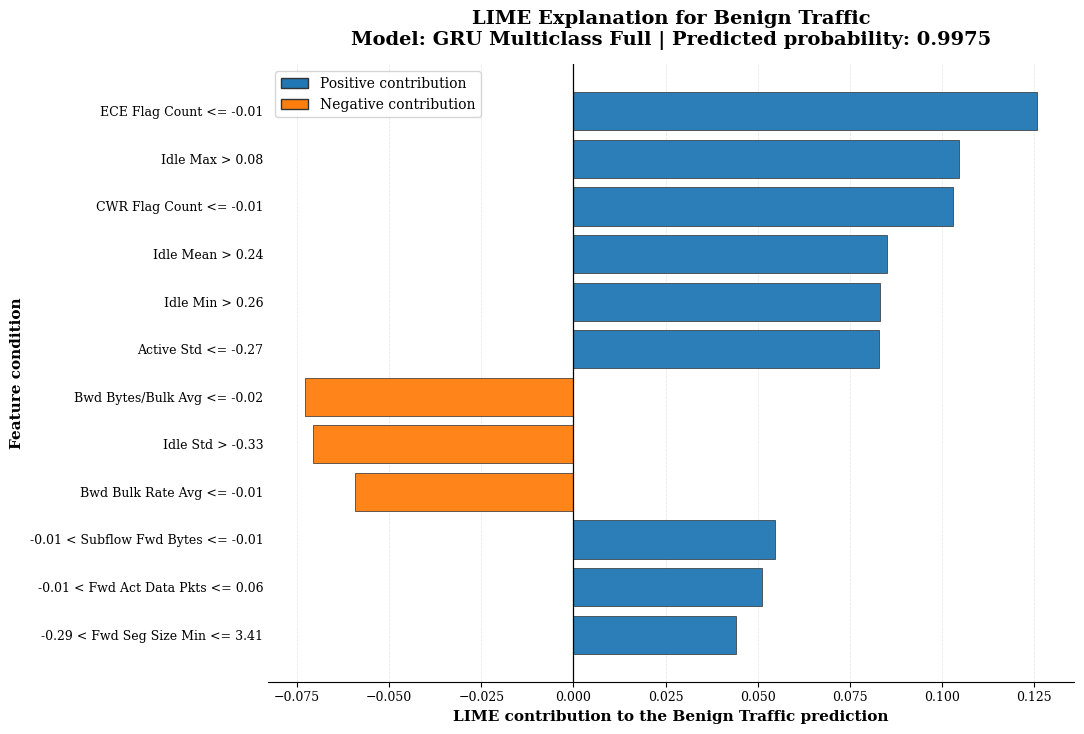


Standard LIME figure saved successfully:
/content/drive/MyDrive/IoMT_Thesis_2024/multiclass_xai/GRU_Multiclass_Full_LIME_Benign_Traffic.png


In [ ]:
# ================================================================
# STANDARD MULTICLASS LIME FIGURE
# ONE REPRESENTATIVE PREDICTION FROM THE SELECTED CLASS
# BEST SAVED DL MODEL — NO RETRAINING
# ================================================================

import os
import gc
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "lime"
        ]
    )
    from lime.lime_tabular import LimeTabularExplainer


# ----------------------------------------------------------------
# 1. Configuration
# ----------------------------------------------------------------

RANDOM_SEED = 42

# Select a class from 0 to 14.
# Run the class-list section below to see the corresponding names.
TARGET_CLASS_INDEX = 0

BACKGROUND_PER_CLASS = 20
CANDIDATE_POOL_SIZE = 1000
LIME_NUM_SAMPLES = 5000
TOP_FEATURES_TO_DISPLAY = 12


# ----------------------------------------------------------------
# 2. Check required notebook variables
# ----------------------------------------------------------------

required_variables = [
    "best_multiclass_model",
    "best_model_name",
    "X_train_scaled",
    "X_test_scaled",
    "y_train",
    "y_test",
    "classes",
    "MULTI_TRAIN_FILE",
    "XAI_PATH",
    "make_predict_function",
    "safe_file_name"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the data-preparation and corrected best-model loading "
        f"cells first. Missing variables: {missing_variables}"
    )


# ----------------------------------------------------------------
# 3. Prepare model, data, classes and features
# ----------------------------------------------------------------

XAI_MODEL = best_multiclass_model
XAI_MODEL_NAME = best_model_name

X_train_xai = np.asarray(
    X_train_scaled,
    dtype=np.float32
)

X_test_xai = np.asarray(
    X_test_scaled,
    dtype=np.float32
)

y_train_xai = np.asarray(
    y_train,
    dtype=np.int32
).reshape(-1)

y_test_xai = np.asarray(
    y_test,
    dtype=np.int32
).reshape(-1)

class_names = [
    str(class_name)
    for class_name in classes
]

number_of_classes = len(
    class_names
)

feature_names = [
    column
    for column in pd.read_csv(
        MULTI_TRAIN_FILE,
        nrows=0
    ).columns.astype(str).tolist()
    if column != "Target"
]

number_of_features = X_train_xai.shape[1]

if number_of_features != len(feature_names):
    raise ValueError(
        f"Feature count mismatch: data={number_of_features}, "
        f"names={len(feature_names)}"
    )

if not (
    0
    <= TARGET_CLASS_INDEX
    < number_of_classes
):
    raise ValueError(
        f"TARGET_CLASS_INDEX must be between 0 and "
        f"{number_of_classes - 1}."
    )

target_class_name = class_names[
    TARGET_CLASS_INDEX
]

predict_2d = make_predict_function(
    XAI_MODEL
)

os.makedirs(
    XAI_PATH,
    exist_ok=True
)


# ----------------------------------------------------------------
# 4. Show available class indices
# ----------------------------------------------------------------

class_mapping_df = pd.DataFrame(
    {
        "Class Index": np.arange(
            number_of_classes
        ),
        "Class Name": class_names
    }
)

display(class_mapping_df)

print("\nSelected class:")
print(
    TARGET_CLASS_INDEX,
    "-",
    target_class_name
)


# ----------------------------------------------------------------
# 5. Create a balanced LIME background
# ----------------------------------------------------------------

random_generator = np.random.default_rng(
    RANDOM_SEED
)

background_indices = []

for class_id in range(
    number_of_classes
):

    class_indices = np.flatnonzero(
        y_train_xai == class_id
    )

    if class_indices.size == 0:
        raise RuntimeError(
            f"No training samples were found for class "
            f"{class_id}: {class_names[class_id]}"
        )

    selected_count = min(
        BACKGROUND_PER_CLASS,
        class_indices.size
    )

    selected_indices = random_generator.choice(
        class_indices,
        size=selected_count,
        replace=False
    )

    background_indices.extend(
        selected_indices.tolist()
    )


background_indices = np.asarray(
    background_indices,
    dtype=np.int64
)

X_lime_background = X_train_xai[
    background_indices
]

print(
    "\nLIME background shape:",
    X_lime_background.shape
)


# ----------------------------------------------------------------
# 6. Select a representative correctly predicted sample
# ----------------------------------------------------------------

target_test_indices = np.flatnonzero(
    y_test_xai
    == TARGET_CLASS_INDEX
)

if target_test_indices.size == 0:
    raise RuntimeError(
        f"No test samples were found for "
        f"{target_class_name}."
    )

candidate_count = min(
    CANDIDATE_POOL_SIZE,
    target_test_indices.size
)

candidate_indices = random_generator.choice(
    target_test_indices,
    size=candidate_count,
    replace=False
)

candidate_probabilities = predict_2d(
    X_test_xai[
        candidate_indices
    ]
)

candidate_predictions = np.argmax(
    candidate_probabilities,
    axis=1
)

correct_positions = np.flatnonzero(
    candidate_predictions
    == TARGET_CLASS_INDEX
)


if correct_positions.size > 0:

    correct_probabilities = candidate_probabilities[
        correct_positions,
        TARGET_CLASS_INDEX
    ]

    median_probability = np.median(
        correct_probabilities
    )

    representative_position = correct_positions[
        np.argmin(
            np.abs(
                correct_probabilities
                - median_probability
            )
        )
    ]

    selection_status = (
        "Correctly classified median-confidence sample"
    )

else:

    representative_position = int(
        np.argmax(
            candidate_probabilities[
                :,
                TARGET_CLASS_INDEX
            ]
        )
    )

    selection_status = (
        "Highest-probability true-class sample; "
        "no correctly classified candidate was found"
    )


selected_test_index = int(
    candidate_indices[
        representative_position
    ]
)

selected_instance = X_test_xai[
    selected_test_index
]

selected_probability_vector = predict_2d(
    selected_instance.reshape(
        1,
        -1
    )
)[0]

selected_prediction_index = int(
    np.argmax(
        selected_probability_vector
    )
)

selected_prediction_name = class_names[
    selected_prediction_index
]

selected_target_probability = float(
    selected_probability_vector[
        TARGET_CLASS_INDEX
    ]
)


print("\nRepresentative sample information")
print("---------------------------------")
print("Test row index       :", selected_test_index)
print("True class           :", target_class_name)
print("Predicted class      :", selected_prediction_name)
print(
    "Target probability  :",
    f"{selected_target_probability:.6f}"
)
print("Selection method     :", selection_status)


# ----------------------------------------------------------------
# 7. Create the LIME explainer
# ----------------------------------------------------------------

lime_explainer = LimeTabularExplainer(
    training_data=X_lime_background,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    discretizer="quartile",
    sample_around_instance=True,
    random_state=RANDOM_SEED
)


# ----------------------------------------------------------------
# 8. Generate the standard LIME explanation
# ----------------------------------------------------------------

lime_explanation = lime_explainer.explain_instance(
    data_row=selected_instance,
    predict_fn=predict_2d,
    labels=(TARGET_CLASS_INDEX,),
    num_features=min(
        TOP_FEATURES_TO_DISPLAY,
        number_of_features
    ),
    num_samples=LIME_NUM_SAMPLES
)


# ----------------------------------------------------------------
# 9. Create the conventional LIME bar figure
# ----------------------------------------------------------------

POSITIVE_COLOR = "#1F77B4"   # Blue
NEGATIVE_COLOR = "#FF7F0E"   # Orange

figure = lime_explanation.as_pyplot_figure(
    label=TARGET_CLASS_INDEX
)

figure.set_size_inches(
    11,
    7.5
)

axis = figure.axes[0]


# ----------------------------------------------------------------
# Recolour the LIME bars according to contribution direction
# ----------------------------------------------------------------

for bar in axis.patches:

    contribution = bar.get_width()

    if contribution >= 0:
        bar.set_facecolor(
            POSITIVE_COLOR
        )
    else:
        bar.set_facecolor(
            NEGATIVE_COLOR
        )

    bar.set_edgecolor(
        "#333333"
    )

    bar.set_linewidth(
        0.55
    )

    bar.set_alpha(
        0.95
    )


# ----------------------------------------------------------------
# Title and axis labels
# ----------------------------------------------------------------

axis.set_title(
    (
        f"LIME Explanation for {target_class_name}\n"
        f"Model: {XAI_MODEL_NAME} | "
        f"Predicted probability: "
        f"{selected_target_probability:.4f}"
    ),
    fontsize=14,
    fontweight="bold",
    pad=14
)

axis.set_xlabel(
    f"LIME contribution to the {target_class_name} prediction",
    fontsize=11,
    fontweight="bold"
)

axis.set_ylabel(
    "Feature condition",
    fontsize=11,
    fontweight="bold"
)


# ----------------------------------------------------------------
# Axis formatting
# ----------------------------------------------------------------

axis.tick_params(
    axis="x",
    labelsize=9
)

axis.tick_params(
    axis="y",
    labelsize=9,
    length=0
)

axis.axvline(
    0,
    color="black",
    linewidth=0.9
)

axis.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.55,
    alpha=0.30
)

axis.set_axisbelow(
    True
)

axis.spines["top"].set_visible(
    False
)

axis.spines["right"].set_visible(
    False
)

axis.spines["left"].set_visible(
    False
)


# ----------------------------------------------------------------
# Custom legend
# ----------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=POSITIVE_COLOR,
        edgecolor="#333333",
        label="Positive contribution"
    ),
    Patch(
        facecolor=NEGATIVE_COLOR,
        edgecolor="#333333",
        label="Negative contribution"
    )
]

axis.legend(
    handles=legend_handles,
    loc="best",
    fontsize=10,
    frameon=True
)

figure.tight_layout()


# ----------------------------------------------------------------
# 10. Save only the PNG
# ----------------------------------------------------------------

safe_class_name = safe_file_name(
    target_class_name
)

lime_png_path = os.path.join(
    XAI_PATH,
    (
        f"{safe_file_name(XAI_MODEL_NAME)}_"
        f"LIME_{safe_class_name}.png"
    )
)

figure.savefig(
    lime_png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(figure)

gc.collect()

print("\nStandard LIME figure saved successfully:")
print(lime_png_path)

LIME background shape: (300, 79)


Representative samples selected: (15, 79)

Generating LIME explanations for all 15 classes...
Completed 01/15: Benign Traffic
Completed 02/15: DDoS ICMP Flood
Completed 03/15: DDoS UDP Flood
Completed 04/15: DoS ICMP Flood
Completed 05/15: DoS TCP Flood
Completed 06/15: DoS UDP Flood
Completed 07/15: MITM ARP Spoofing
Completed 08/15: MQTT DDoS Publish Flood
Completed 09/15: MQTT DoS Connect Flood
Completed 10/15: MQTT DoS Publish Flood
Completed 11/15: MQTT Malformed
Completed 12/15: Recon OS Scan
Completed 13/15: Recon Ping Sweep
Completed 14/15: Recon Port Scan
Completed 15/15: Recon Vulnerability Scan


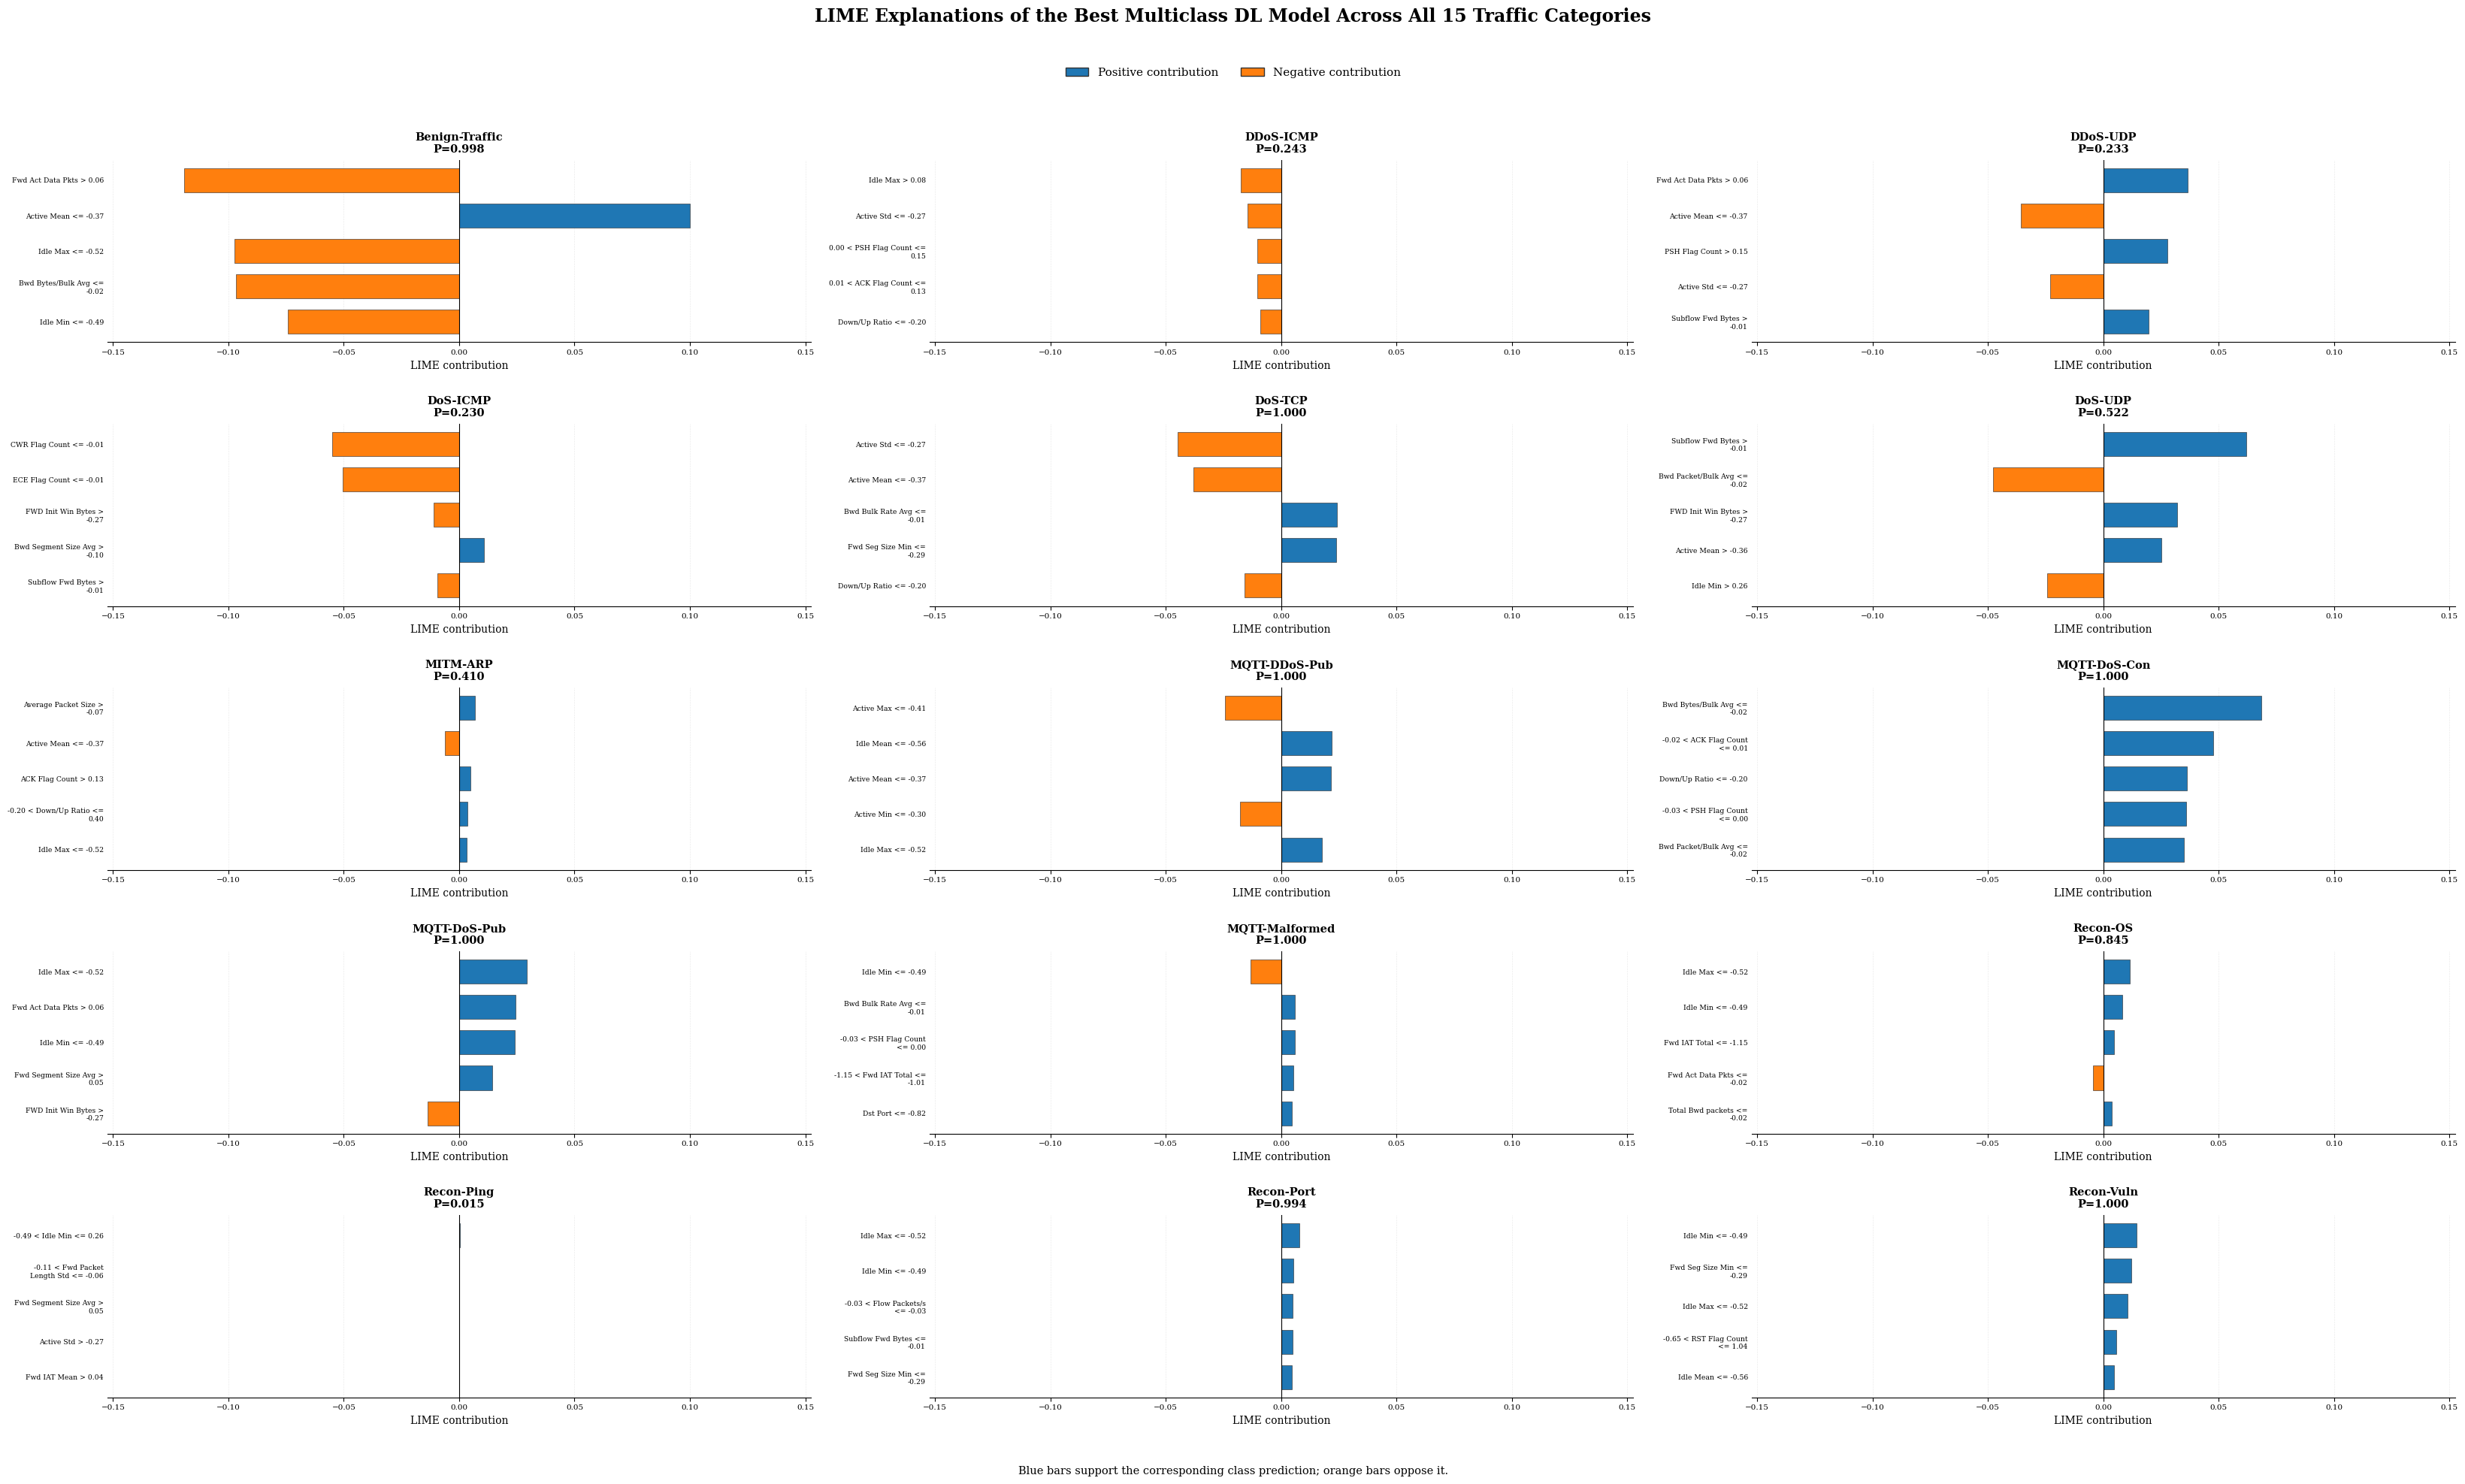


Combined multiclass LIME figure saved successfully:
/content/drive/MyDrive/IoMT_Thesis_2024/multiclass_xai/GRU_Multiclass_Full_Combined_LIME_All_15_Classes.png


In [ ]:
# ================================================================
# COMBINED STANDARD MULTICLASS LIME FIGURE
# ALL 15 CLASSES IN ONE CONFERENCE-READY PNG
# POSITIVE = BLUE, NEGATIVE = ORANGE
# BEST SAVED DL MODEL — NO RETRAINING
# ================================================================

import os
import gc
import sys
import subprocess
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch


try:
    from lime.lime_tabular import LimeTabularExplainer

except ImportError:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "lime"
        ]
    )

    from lime.lime_tabular import LimeTabularExplainer


# ----------------------------------------------------------------
# 1. Configuration
# ----------------------------------------------------------------

RANDOM_SEED = 42

BACKGROUND_PER_CLASS = 20
CANDIDATE_POOL_SIZE = 500

LIME_NUM_SAMPLES = 3000

# A small value is necessary so that all 15 panels remain readable.
TOP_FEATURES_PER_CLASS = 5

POSITIVE_COLOR = "#1F77B4"
NEGATIVE_COLOR = "#FF7F0E"


# ----------------------------------------------------------------
# 2. Check required notebook variables
# ----------------------------------------------------------------

required_variables = [
    "best_multiclass_model",
    "best_model_name",
    "X_train_scaled",
    "X_test_scaled",
    "y_train",
    "y_test",
    "classes",
    "MULTI_TRAIN_FILE",
    "XAI_PATH",
    "make_predict_function",
    "safe_file_name"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Run the data-preparation and best-model loading cells first. "
        f"Missing variables: {missing_variables}"
    )


# ----------------------------------------------------------------
# 3. Prepare model, data, class names and feature names
# ----------------------------------------------------------------

XAI_MODEL = best_multiclass_model
XAI_MODEL_NAME = best_model_name

X_train_xai = np.asarray(
    X_train_scaled,
    dtype=np.float32
)

X_test_xai = np.asarray(
    X_test_scaled,
    dtype=np.float32
)

y_train_xai = np.asarray(
    y_train,
    dtype=np.int32
).reshape(-1)

y_test_xai = np.asarray(
    y_test,
    dtype=np.int32
).reshape(-1)

class_names = [
    str(class_name)
    for class_name in classes
]

number_of_classes = len(
    class_names
)

if number_of_classes != 15:

    raise ValueError(
        f"Expected 15 classes, but found {number_of_classes}."
    )


feature_names = [
    column
    for column in pd.read_csv(
        MULTI_TRAIN_FILE,
        nrows=0
    ).columns.astype(str).tolist()
    if column != "Target"
]

number_of_features = X_train_xai.shape[1]

if number_of_features != len(feature_names):

    raise ValueError(
        f"Feature count mismatch: data={number_of_features}, "
        f"names={len(feature_names)}"
    )


predict_2d = make_predict_function(
    XAI_MODEL
)

os.makedirs(
    XAI_PATH,
    exist_ok=True
)


# ----------------------------------------------------------------
# 4. Short class names for compact figure titles
# ----------------------------------------------------------------

short_class_name_map = {
    "Benign": "Benign",
    "DDoS ICMP Flood": "DDoS-ICMP",
    "DDoS UDP Flood": "DDoS-UDP",
    "DoS ICMP Flood": "DoS-ICMP",
    "DoS TCP Flood": "DoS-TCP",
    "DoS UDP Flood": "DoS-UDP",
    "MITM ARP Spoofing": "MITM-ARP",
    "MQTT DDoS Publish Flood": "MQTT-DDoS-Pub",
    "MQTT DoS Connect Flood": "MQTT-DoS-Con",
    "MQTT DoS Publish Flood": "MQTT-DoS-Pub",
    "MQTT Malformed": "MQTT-Malformed",
    "Recon OS Scan": "Recon-OS",
    "Recon Ping Sweep": "Recon-Ping",
    "Recon Port Scan": "Recon-Port",
    "Recon Vulnerability Scan": "Recon-Vuln"
}

short_class_names = [
    short_class_name_map.get(
        class_name,
        class_name.replace(" ", "-")
    )
    for class_name in class_names
]


# ----------------------------------------------------------------
# 5. Create a balanced LIME background
# ----------------------------------------------------------------

random_generator = np.random.default_rng(
    RANDOM_SEED
)

background_indices = []

for class_id in range(
    number_of_classes
):

    class_indices = np.flatnonzero(
        y_train_xai == class_id
    )

    if class_indices.size == 0:

        raise RuntimeError(
            f"No training samples were found for class "
            f"{class_id}: {class_names[class_id]}"
        )

    selected_count = min(
        BACKGROUND_PER_CLASS,
        class_indices.size
    )

    selected_indices = random_generator.choice(
        class_indices,
        size=selected_count,
        replace=False
    )

    background_indices.extend(
        selected_indices.tolist()
    )


background_indices = np.asarray(
    background_indices,
    dtype=np.int64
)

X_lime_background = X_train_xai[
    background_indices
]

print(
    "LIME background shape:",
    X_lime_background.shape
)


# ----------------------------------------------------------------
# 6. Select one representative correctly classified sample
#    from each of the 15 classes
# ----------------------------------------------------------------

representative_indices = []
representative_probabilities = []
representative_predictions = []

for class_id in range(
    number_of_classes
):

    target_indices = np.flatnonzero(
        y_test_xai == class_id
    )

    if target_indices.size == 0:

        raise RuntimeError(
            f"No test samples were found for class "
            f"{class_id}: {class_names[class_id]}"
        )

    candidate_count = min(
        CANDIDATE_POOL_SIZE,
        target_indices.size
    )

    candidate_indices = random_generator.choice(
        target_indices,
        size=candidate_count,
        replace=False
    )

    candidate_probabilities = predict_2d(
        X_test_xai[
            candidate_indices
        ]
    )

    candidate_predictions = np.argmax(
        candidate_probabilities,
        axis=1
    )

    correct_positions = np.flatnonzero(
        candidate_predictions == class_id
    )

    if correct_positions.size > 0:

        correct_class_probabilities = candidate_probabilities[
            correct_positions,
            class_id
        ]

        median_probability = np.median(
            correct_class_probabilities
        )

        selected_position = correct_positions[
            np.argmin(
                np.abs(
                    correct_class_probabilities
                    - median_probability
                )
            )
        ]

    else:

        selected_position = int(
            np.argmax(
                candidate_probabilities[
                    :,
                    class_id
                ]
            )
        )

        print(
            "Warning: no correctly predicted candidate for:",
            class_names[class_id],
            "- using the highest target-probability sample."
        )


    selected_index = int(
        candidate_indices[
            selected_position
        ]
    )

    selected_probability = float(
        candidate_probabilities[
            selected_position,
            class_id
        ]
    )

    selected_prediction = int(
        candidate_predictions[
            selected_position
        ]
    )

    representative_indices.append(
        selected_index
    )

    representative_probabilities.append(
        selected_probability
    )

    representative_predictions.append(
        selected_prediction
    )


representative_indices = np.asarray(
    representative_indices,
    dtype=np.int64
)

representative_probabilities = np.asarray(
    representative_probabilities,
    dtype=np.float64
)

representative_predictions = np.asarray(
    representative_predictions,
    dtype=np.int32
)

representative_data = X_test_xai[
    representative_indices
]


print(
    "Representative samples selected:",
    representative_data.shape
)


# ----------------------------------------------------------------
# 7. Create the LIME explainer
# ----------------------------------------------------------------

lime_explainer = LimeTabularExplainer(
    training_data=X_lime_background,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    discretizer="quartile",
    sample_around_instance=True,
    random_state=RANDOM_SEED
)


# ----------------------------------------------------------------
# 8. Generate all 15 LIME explanations
# ----------------------------------------------------------------

all_explanations = []

print("\nGenerating LIME explanations for all 15 classes...")

for class_id in range(
    number_of_classes
):

    explanation = lime_explainer.explain_instance(
        data_row=representative_data[
            class_id
        ],
        predict_fn=predict_2d,
        labels=(class_id,),
        num_features=min(
            TOP_FEATURES_PER_CLASS,
            number_of_features
        ),
        num_samples=LIME_NUM_SAMPLES
    )

    explanation_items = explanation.as_list(
        label=class_id
    )

    all_explanations.append(
        explanation_items
    )

    print(
        f"Completed {class_id + 1:02d}/15:",
        class_names[class_id]
    )


# ----------------------------------------------------------------
# 9. Find a common symmetric x-axis limit
# ----------------------------------------------------------------

all_contribution_values = []

for explanation_items in all_explanations:

    for _, contribution in explanation_items:

        all_contribution_values.append(
            abs(
                float(contribution)
            )
        )


maximum_contribution = max(
    all_contribution_values,
    default=1e-8
)

common_axis_limit = (
    maximum_contribution * 1.28
)


# ----------------------------------------------------------------
# 10. Create ONE figure containing 15 standard LIME panels
#     3 rows × 5 columns
# ----------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(34, 20),
    facecolor="white"
)

axes = axes.flatten()


for class_id, axis in enumerate(
    axes
):

    explanation_items = all_explanations[
        class_id
    ]

    feature_conditions = [
        str(item[0])
        for item in explanation_items
    ]

    contributions = np.asarray(
        [
            float(item[1])
            for item in explanation_items
        ],
        dtype=np.float64
    )


    # Place the highest absolute contribution at the top.
    order = np.argsort(
        np.abs(
            contributions
        )
    )

    feature_conditions = [
        feature_conditions[index]
        for index in order
    ]

    contributions = contributions[
        order
    ]


    wrapped_conditions = [
        "\n".join(
            textwrap.wrap(
                condition,
                width=24
            )
        )
        for condition in feature_conditions
    ]


    bar_colors = [
        POSITIVE_COLOR
        if contribution >= 0
        else NEGATIVE_COLOR
        for contribution in contributions
    ]


    y_positions = np.arange(
        len(contributions)
    )


    bars = axis.barh(
        y_positions,
        contributions,
        color=bar_colors,
        edgecolor="#333333",
        linewidth=0.45,
        height=0.68
    )


    axis.axvline(
        0,
        color="black",
        linewidth=0.8
    )


    axis.set_xlim(
        -common_axis_limit,
        common_axis_limit
    )


    axis.set_yticks(
        y_positions
    )

    axis.set_yticklabels(
        wrapped_conditions,
        fontsize=6.7
    )


    predicted_name = short_class_names[
        representative_predictions[
            class_id
        ]
    ]


    axis.set_title(
        (
            f"{short_class_names[class_id]}\n"
            f"P={representative_probabilities[class_id]:.3f}"
        ),
        fontsize=10.5,
        fontweight="bold",
        pad=7
    )


    axis.set_xlabel(
        "LIME contribution",
        fontsize=10
    )


    axis.tick_params(
        axis="x",
        labelsize=7.5
    )

    axis.tick_params(
        axis="y",
        length=0
    )


    axis.xaxis.grid(
        True,
        linestyle="--",
        linewidth=0.45,
        alpha=0.28
    )

    axis.set_axisbelow(True)


    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)


# ----------------------------------------------------------------
# 11. Global legend and title
# ----------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=POSITIVE_COLOR,
        edgecolor="#333333",
        label="Positive contribution"
    ),
    Patch(
        facecolor=NEGATIVE_COLOR,
        edgecolor="#333333",
        label="Negative contribution"
    )
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=2,
    frameon=False,
    fontsize=11
)


fig.suptitle(
    (
        "LIME Explanations of the Best Multiclass DL Model "
        "Across All 15 Traffic Categories"
    ),
    fontsize=17,
    fontweight="bold",
    y=0.988
)


fig.text(
    0.5,
    0.012,
    (
        "Blue bars support the corresponding class prediction; "
        "orange bars oppose it."
    ),
    ha="center",
    fontsize=10.5
)


fig.tight_layout(
    rect=[
        0.015,
        0.035,
        0.985,
        0.935
    ],
    h_pad=2.0,
    w_pad=1.1
)


# ----------------------------------------------------------------
# 12. Save only ONE PNG
# ----------------------------------------------------------------

combined_lime_png = os.path.join(
    XAI_PATH,
    (
        f"{safe_file_name(XAI_MODEL_NAME)}_"
        "Combined_LIME_All_15_Classes.png"
    )
)

fig.savefig(
    combined_lime_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


# ----------------------------------------------------------------
# 13. Release memory
# ----------------------------------------------------------------

del (
    X_lime_background,
    representative_data,
    all_explanations
)

gc.collect()


print("\nCombined multiclass LIME figure saved successfully:")
print(combined_lime_png)

In [ ]:
# ================================================================
# BEST MODEL ARCHITECTURE / PARAMETER SUMMARY — NO DRIVE DUPLICATES
# ================================================================
# The notebook already stores only best_multiclass_model.weights.h5.
# This cell DOES NOT create another .keras, .h5, or weights copy in Drive.
# If you need a Netron file temporarily, it is created under /content only.
# ================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

if not os.path.exists(MULTI_RESULT_FILE):
    raise FileNotFoundError("Run at least one model first.")

results_df = pd.read_csv(MULTI_RESULT_FILE).sort_values("F1", ascending=False)
best_model_name = str(results_df.iloc[0]["Model"])
best_model_f1 = float(results_df.iloc[0]["F1"])

if not os.path.exists(BEST_WEIGHTS_FILE):
    raise FileNotFoundError(BEST_WEIGHTS_FILE)

if best_model_name not in MODEL_BUILDERS:
    raise KeyError(best_model_name)

tf.keras.backend.clear_session()
best_model = MODEL_BUILDERS[best_model_name]()
best_model.load_weights(BEST_WEIGHTS_FILE)

total_parameters = int(best_model.count_params())
trainable_parameters = int(sum(np.prod(v.shape) for v in best_model.trainable_weights))
non_trainable_parameters = int(sum(np.prod(v.shape) for v in best_model.non_trainable_weights))

parameter_summary_df = pd.DataFrame([{
    "Model": best_model_name,
    "Weighted F1": best_model_f1,
    "Input Shape": str(best_model.input_shape),
    "Output Shape": str(best_model.output_shape),
    "Total Parameters": total_parameters,
    "Trainable Parameters": trainable_parameters,
    "Non-trainable Parameters": non_trainable_parameters
}])

display(parameter_summary_df)

print("\nPermanent Drive model artifact:")
print(BEST_WEIGHTS_FILE)
print("No duplicate Netron files were saved to Drive.")

# OPTIONAL: temporary Netron model in Colab local storage only.
# Uncomment these two lines only when you actually need Netron:
# TEMP_NETRON_FILE = "/content/best_multiclass_model_for_netron.keras"
# best_model.save(TEMP_NETRON_FILE)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,Model,Weighted F1,Input Shape,Output Shape,Total Parameters,Trainable Parameters,Non-trainable Parameters
0,GRU Multiclass Full,0.980079,"(None, 79, 1)","(None, 15)",59535,59535,0



Permanent Drive model artifact:
/content/drive/MyDrive/IoMT_Thesis_2024/multiclass_dl_models/best_multiclass_model.weights.h5
No duplicate Netron files were saved to Drive.
